# Dataset Analysis on Gag Lattice Eccentricity and Size

**Date:** Mar 11, 2025  
**Author:** yying7@jh.edu  

---

## Input File Naming

Input files are named according to the **major and minor axis lengths** (`a`, `b`) of the gag lattice in nanometers. These correspond to the ellipse equation:

$$
\frac{x^2}{a^2} + \frac{y^2}{b^2} = 1
$$

For example:

- `...a40_b30.csv` refers to the ellipse:  
  $$
  \frac{x^2}{40^2} + \frac{y^2}{30^2} = 1
  $$

### Eccentricity Definition

Eccentricity is defined as:

$$
\text{ecc} = \sqrt{1 - \frac{b^2}{a^2}}
$$

Used TrialGroups (The following group shows `SizeGroup` of `40` (nm)):

| TrialGroup | Major Axis (nm) | Minor Axis (nm) | Eccentricity |
|------------|------------------|------------------|--------------|
| 0          | 40               | 40               | 0.000        |
| 1          | 40               | 30               | 0.66143782776 |
| 2          | 40               | 24               | 0.8          |
| 3          | 40               | 20               | 0.86602540378 |
| 4          | 40               | 16               | 0.91651513899 |

### TrialGroup and SizeGroup Definitions

- **TrialGroups** are based on different eccentricities (as above).
- **SizeGroups** are defined by the **major axis length** `a`.

> Note: Eccentricities were **not sampled uniformly**, because both **geometry** and **energy effects** are nonlinear in eccentricity.  
> Sampling more between 0.0 and 0.661 would cause **overcrowding in plots** (e.g., EB vs. Ngags by eccentricity).

---

## Extra Trials for 35 nm and 40 nm Major Axis Groups

Extra trials were run for:
- **a = 40 nm** → `ecca41`, `ecca42`, `ecca43`
- **a = 35 nm** → `ecca44`

Reason:
> The original `S0` ranges caused **non-convergence** in simulations for these groups.

Thus, these trials are **merged** back into:
- `ecca40` (includes `ecca41` to `ecca43`)
- `ecca35` (includes `ecca44`)

This causes **larger sample sizes** for `ecca40` and `ecca35` compared to smaller scaffold caps.

Refer to the code section:
```python
# Read and pre-process the dataset
# Concat extra trial for size group 40 nm and size group 35 nm
```

---

## Known Data Issue (Fixed)

There was an error in the following entry:

```
18	3	10	228.05900	228.06600	2.601	2.601	71	0.866025
```

- **Issue Date:** March 11
- **Fixed On:** March 18
- **Cause:** `COM.csv` file was incorrect — `Ngags = 71` was wrong.

---

## Theoretical Model

The models are based on two theoretical regimes:

1. **No tension**
2. **SGA** and **non-SGA** models


# 0. Import Packages and Set `rcParams` for plotting

[]

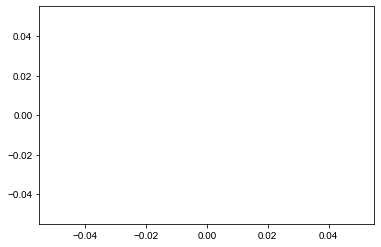

In [1]:
#!/usr/bin/env python3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import itertools
# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'
# Set global math and font config
matplotlib.rcParams["mathtext.fontset"] = "cm"      # Use Computer Modern for mathtext

import seaborn as sns
import os

plt.plot()
sns.set_context("talk")
plt.plot()

# 1. Read and pre-process the dataset

In [2]:
df_results = pd.read_csv("./results/results.csv")
df_results

,Folder,RelaxArea,Col1,Col2,Col3,Col4,Col5,Ngags,Height
0,_ecca10_01,74000.0,5.82954,0.000016,0.000833,5.85068,0.000115,20,2.175345
1,_ecca10_02,74500.0,5.96413,0.000016,0.000000,5.97588,0.000163,20,2.211185
2,_ecca10_03,75000.0,5.92572,0.000016,0.001224,5.93884,0.000143,20,2.211813
3,_ecca10_04,75500.0,6.15496,0.000018,0.000134,6.16718,0.000145,20,2.276765
4,_ecca10_05,76000.0,6.23171,0.000018,0.000214,6.24330,0.000414,20,2.301945
...,...,...,...,...,...,...,...,...,...
323,_ecca44_34,79500.0,410.36600,0.013694,0.000000,410.39500,0.000743,219,48.011041
324,_ecca44_35,80000.0,418.67000,0.014000,0.000000,418.70200,0.001068,219,48.240683
325,_ecca44_36,80500.0,528.77200,8.006060,0.000000,537.07000,0.008017,219,48.430955
326,_ecca44_37,81000.0,616.25300,384.031000,0.000000,1000.64000,0.014852,219,48.565993


## 1.1. Preprocess the dataset and merge the ecca40+ trials back into corresponding trial groups

### ! See the start of the file in section "Extra Trials for 35 nm and 40 nm Major Axis Group" for more information

In [3]:
df_results = pd.read_csv("./results/results.csv")

# Reset column names
# EB: bending energy
# EA: area constraint energy
# ER: regularization energy (should converge to near 0)
# Etot: total energy
# MeanForce: mean force on every node
df_results.columns = ['FolderName', 'RelaxArea', 'EB', 'EA', 'ER', 'Etot', 'MeanForce', 'Ngags', 'Height']

# extracts the last two digits in the name,
# and save in TrialGroup and TrialNum respectively.
# e.g. _fixedmc_01, then TrialGroup is 0 and TrialNum is 1.
# Assuming df_results is already loaded
df_results['SizeGroup'] = df_results['FolderName'].apply(lambda x: int(x[-5:-3]))
df_results['TrialGroup'] = df_results['FolderName'].apply(lambda x: int(x.split('_')[-1]) // 10)
df_results['TrialNum'] = df_results['FolderName'].apply(lambda x: int(x.split('_')[-1]) % 10)

# Concat extra trial for size group 40 nm and size group 35 nm
# Fix indexing (rerun 40 as 41)
df_results.loc[df_results['SizeGroup'] == 41, "TrialNum"] += 10
df_results.loc[df_results['SizeGroup'] == 41, "SizeGroup"] = 40
# Fix indexing (rerun 40 as 42, for two eccentricities)
df_results.loc[df_results['SizeGroup'] == 42, "TrialNum"] += 20
df_results.loc[df_results['SizeGroup'] == 42, "TrialGroup"] += 1
df_results.loc[df_results['SizeGroup'] == 42, "SizeGroup"] = 40
# Fix indexing (rerun 40 as 43, for two eccentricities)
df_results.loc[df_results['SizeGroup'] == 43, "TrialNum"] += 30
df_results.loc[(df_results['SizeGroup'] == 43) & (df_results['Ngags'] == 106), "TrialGroup"] += 2
df_results.loc[(df_results['SizeGroup'] == 43) & (df_results['Ngags'] == 137), "TrialGroup"] += 2
df_results.loc[df_results['SizeGroup'] == 43, "SizeGroup"] = 40
# Fin indexing (rerun 40 as 44, for one last eccentricity)
df_results.loc[df_results['SizeGroup'] == 44, "TrialNum"] += 40
df_results.loc[(df_results['SizeGroup'] == 44) & (df_results['Ngags'] == 219), "TrialGroup"] = 0
df_results.loc[(df_results['SizeGroup'] == 44) & (df_results['Ngags'] == 105), "TrialGroup"] = 3
df_results.loc[df_results['SizeGroup'] == 44, "SizeGroup"] = 35

# Get eccentricity from mapping
# TrialGroup 0: ecc = 0.0 (40,40)
# TrialGroup 1: ecc = 0.66143782776 (40,30)
# TrialGroup 2: ecc = 0.8 (40,24)
# TrialGroup 3: ecc = 0.86602540378 (40,20)
# TrialGroup 4: ecc = 0.91651513899 (40,16)
if 'Ecc' not in df_results.columns:
    df_results['Ecc'] = None
df_results.loc[df_results['TrialGroup'] == 0, "Ecc"] = 0.0
df_results.loc[df_results['TrialGroup'] == 1, "Ecc"] = 0.66143782776
df_results.loc[df_results['TrialGroup'] == 2, "Ecc"] = 0.8
df_results.loc[df_results['TrialGroup'] == 3, "Ecc"] = 0.86602540378
df_results.loc[df_results['TrialGroup'] == 4, "Ecc"] = 0.91651513899

df_results

,FolderName,RelaxArea,EB,EA,ER,Etot,MeanForce,Ngags,Height,SizeGroup,TrialGroup,TrialNum,Ecc
0,_ecca10_01,74000.0,5.82954,0.000016,0.000833,5.85068,0.000115,20,2.175345,10,0,1,0.0
1,_ecca10_02,74500.0,5.96413,0.000016,0.000000,5.97588,0.000163,20,2.211185,10,0,2,0.0
2,_ecca10_03,75000.0,5.92572,0.000016,0.001224,5.93884,0.000143,20,2.211813,10,0,3,0.0
3,_ecca10_04,75500.0,6.15496,0.000018,0.000134,6.16718,0.000145,20,2.276765,10,0,4,0.0
4,_ecca10_05,76000.0,6.23171,0.000018,0.000214,6.24330,0.000414,20,2.301945,10,0,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,_ecca44_34,79500.0,410.36600,0.013694,0.000000,410.39500,0.000743,219,48.011041,35,0,44,0.0
324,_ecca44_35,80000.0,418.67000,0.014000,0.000000,418.70200,0.001068,219,48.240683,35,0,45,0.0
325,_ecca44_36,80500.0,528.77200,8.006060,0.000000,537.07000,0.008017,219,48.430955,35,0,46,0.0
326,_ecca44_37,81000.0,616.25300,384.031000,0.000000,1000.64000,0.014852,219,48.565993,35,0,47,0.0


## 1.2. Define bootstrap test of minimum

In [4]:
# Function to perform resampling to estimate error of minimum energy
def resampling_min_error(data, num_samples=10000, confidence=0.95):
    """
    Perform a bootstrap resampling test to estimate the error of the minimum energy in each GagDistance group.
    
    The process involves:
    - Randomly resampling (with replacement) the energy values in the group.
    - Computing the minimum energy for each resampled dataset.
    - Calculating the upper bound error based on a one-sided confidence interval.

    Args:
    - data: The energy values of a given group.
    - num_samples: Number of bootstrap samples to generate.
    - confidence: Confidence level for the upper bound error estimation.

    Returns:
    - The upper error estimate for the minimum energy.
    """
    min_values = []
    for _ in range(num_samples):
        resampled_data = np.random.choice(data, size=len(data), replace=True)
        min_values.append(np.min(resampled_data))
    
    #print(min_values)
    # Compute the one-sided error bound at the given confidence level
    error = np.percentile(min_values, (confidence) * 100) - np.min(data)
    #print(error)
    return error

## 1.3. Calculate tension from the dataset



$$ \tau = \frac{\partial E_{\text{A}}}{\partial A} $$

---


$$E_A = \frac{1}{2} \mu \frac{(A - A_0)^2}{A_0}$$

Differentiate w.r.t. A:

$$\tau = \frac{dE}{dA} = \frac{1}{2} \mu \cdot \frac{2(A - A_0)}{A_0} = \mu \cdot \frac{A - A_0}{A_0}$$

---

$$\tau = \sqrt{\frac{2\mu E_{\text{A}}}{A_0}}$$

In [5]:
df_results["Tension"] = np.sqrt(2 * 250.0 * df_results["EA"] / df_results["RelaxArea"])
df_results

,FolderName,RelaxArea,EB,EA,ER,Etot,MeanForce,Ngags,Height,SizeGroup,TrialGroup,TrialNum,Ecc,Tension
0,_ecca10_01,74000.0,5.82954,0.000016,0.000833,5.85068,0.000115,20,2.175345,10,0,1,0.0,0.000330
1,_ecca10_02,74500.0,5.96413,0.000016,0.000000,5.97588,0.000163,20,2.211185,10,0,2,0.0,0.000330
2,_ecca10_03,75000.0,5.92572,0.000016,0.001224,5.93884,0.000143,20,2.211813,10,0,3,0.0,0.000329
3,_ecca10_04,75500.0,6.15496,0.000018,0.000134,6.16718,0.000145,20,2.276765,10,0,4,0.0,0.000343
4,_ecca10_05,76000.0,6.23171,0.000018,0.000214,6.24330,0.000414,20,2.301945,10,0,5,0.0,0.000348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,_ecca44_34,79500.0,410.36600,0.013694,0.000000,410.39500,0.000743,219,48.011041,35,0,44,0.0,0.009280
324,_ecca44_35,80000.0,418.67000,0.014000,0.000000,418.70200,0.001068,219,48.240683,35,0,45,0.0,0.009354
325,_ecca44_36,80500.0,528.77200,8.006060,0.000000,537.07000,0.008017,219,48.430955,35,0,46,0.0,0.222996
326,_ecca44_37,81000.0,616.25300,384.031000,0.000000,1000.64000,0.014852,219,48.565993,35,0,47,0.0,1.539663


## 1.4. Joint Bootstrap for Minimum `E_tot` and Associated Error Estimation

Perform joint bootstrapping to estimate uncertainties in energy-related quantities, conditioned on minimizing the total energy (Etot). The method samples entire rows to preserve the relationships among Etot, EB, EA, and Tension.

### 1.4.1. Group the data by `TrialGroup` and `SizeGroup` and get minimum `E_tot` in each group

Note: In each `TrialGroup`, eccentricity is the same. In each `SizeGroup`,  elliptical major axis length of the cap is the same.

In [6]:
# Group by GagDistance and compute the minimum values
grouped_df = df_results.groupby(["TrialGroup", "SizeGroup"],\
                                group_keys=False).apply(lambda g: g.loc[g['Etot'].idxmin()])
grouped_df

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_71840/4193248261.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_df = df_results.groupby(["TrialGroup", "SizeGroup"],\


FolderName  RelaxArea         EB        EA  \
TrialGroup SizeGroup                                               
0          10         _ecca10_01    74000.0    5.82954  0.000016   
           20         _ecca20_01    74000.0   67.22260  0.000846   
           25         _ecca25_04    75500.0  131.92200  0.001716   
           30         _ecca30_04    75500.0  219.94600  0.004056   
           35         _ecca44_31    78000.0  377.34300  0.009175   
           40         _ecca43_01    82000.0  584.87000  0.016471   
1          10         _ecca10_13    75000.0    4.41255  0.000017   
           20         _ecca20_13    75000.0   47.83820  0.000335   
           25         _ecca25_12    74500.0   96.39730  0.001190   
           30         _ecca30_14    75500.0  214.33600  0.005303   
           35         _ecca35_16    76500.0  316.36600  0.008495   
           40         _ecca42_05    84000.0  627.90700  0.015703   
2          10         _ecca10_21    74000.0    6.19292  0.000058   
           20         _ecca20_22    74500.0   50.31450  0.000449   
           25         _ecca25_23    75000.0  100.73600  0.001269   
           30         _ecca30_26    76500.0  187.04500  0.003726   
           35         _ecca35_26    76500.0  292.69700  0.006896   
           40         _ecca42_13    83000.0  567.87300  0.010918   
3          10         _ecca10_33    76000.0    4.39010  0.000022   
           20         _ecca20_33    75000.0   43.41970  0.000502   
           25         _ecca25_34    75500.0   91.97770  0.001202   
           30         _ecca30_34    75500.0  192.35100  0.004824   
           35         _ecca35_37    77000.0  335.42800  0.010503   
           40         _ecca41_36    80500.0  497.93500  0.012520   
4          10         _ecca10_41    74000.0    2.06577  0.000009   
           20         _ecca20_44    75500.0   36.39130  0.000246   
           25         _ecca25_43    75000.0  103.52300  0.002187   
           30         _ecca30_43    75000.0  156.41900  0.003251   
           35         _ecca35_45    76000.0  248.91800  0.005902   
           40         _ecca41_48    81500.0  565.26500  0.020884   

                                ER       Etot  MeanForce  Ngags     Height  \
TrialGroup SizeGroup                                                         
0          10         8.334640e-04    5.85068   0.000115     20   2.175345   
           20         0.000000e+00   67.24280   0.000464     70  12.622531   
           25         0.000000e+00  131.93000   0.000650    107  22.518314   
           30         0.000000e+00  219.95700   0.001183    156  31.769624   
           35         0.000000e+00  377.36200   0.001387    219  47.320670   
           40         0.000000e+00  584.93800   0.001363    302  67.070502   
1          10         3.139850e-03    4.42141   0.000140     14   2.254168   
           20         0.000000e+00   47.85790   0.001738     53  11.127442   
           25         0.000000e+00   96.40480   0.000502     80  17.891542   
           30         0.000000e+00  214.34500   0.000924    116  30.261026   
           35         0.000000e+00  316.38000   0.000920    161  40.406735   
           40         0.000000e+00  627.94000   0.001270    216  73.673011   
2          10         5.690060e-03    6.20265   0.000254     11   2.723758   
           20         0.000000e+00   50.32890   0.000852     43  12.020672   
           25         7.277960e-08  100.74400   0.000408     65  19.214316   
           30         4.930300e-09  187.05300   0.000663     91  28.251547   
           35         0.000000e+00  292.70800   0.000715    124  40.125334   
           40         0.000000e+00  567.88700   0.000798    163  72.018418   
3          10         3.512640e-03    4.39852   0.000057     10   2.124637   
           20         1.832160e-03   43.43520   0.000393     35  10.013464   
           25         1.169370e-10   91.98720   0.000633     52  17.792698   
           30         0.000000e+00  192.36500   0.0

### 1.4.2. Define Joint Bootstrapping

### Methodology
- In each bootstrap iteration:
  - Rows are resampled **with replacement**.
  - The row with the **minimum `Etot`** is identified in each sample.
  - The corresponding `EB`, `EA`, and `Tension` values are recorded from that same row.
- After all iterations:
  - A **one-sided confidence interval** is computed for `Etot` (upper bound only).
  - **Two-sided confidence intervals** are computed for `EB`, `EA`, and `Tension`.

This ensures physical consistency across variables by maintaining row-wise dependencies in each sample.

---

### Arguments

| Argument          | Type    | Description                                                                 |
|------------------|---------|-----------------------------------------------------------------------------|
| `df_subset`       | DataFrame | Must contain columns: `Etot`, `EB`, `EA`, `Tension` for a single group |
| `num_samples`     | int     | Number of bootstrap samples (default = 10,000)                             |
| `confidence`      | float   | One-sided confidence level for `Etot` (e.g., `0.95`)                        |
| `joint_confidence`| float   | Two-sided confidence level for `EB`, `EA`, and `Tension` (e.g., `0.95`)     |

---

### Returns

A dictionary of estimated bootstrap errors:

```python
{
    "Etot_err": ...       # One-sided upper bound for Etot
    "EB_err": ...         # Half-width of two-sided CI for EB
    "EA_err": ...         # Half-width of two-sided CI for EA
    "Tension_err": ...    # Half-width of two-sided CI for Tension
}
```

In [24]:
def resampling_joint_min_error(
    df_subset, 
    num_samples=10000, 
    confidence=0.95,
    joint_confidence=0.90
):
    data = df_subset[['Etot', 'EB', 'EA', 'Tension', 'Height']].to_numpy()
    n = len(data)

    # Generate indices: shape (num_samples, n)
    sample_indices = np.random.randint(0, n, size=(num_samples, n))

    # Resample all data in one go: shape (num_samples, n, 4)
    resampled = data[sample_indices]

    # Extract Etot column (index 0): shape (num_samples, n)
    etot_vals = resampled[:, :, 0]

    # Find index of min Etot for each resample
    min_indices = np.argmin(etot_vals, axis=1)  # shape (num_samples,)

    # Use advanced indexing to gather the rows where Etot is minimal
    row_indices = np.arange(num_samples)
    min_rows = resampled[row_indices, min_indices]  # shape (num_samples, 4)

    # Extract columns
    etot_mins = min_rows[:, 0]
    eb_mins = min_rows[:, 1]
    ea_mins = min_rows[:, 2]
    tension_mins = min_rows[:, 3]
    height_mins = min_rows[:, 4]
    ea_ratio_mins = ea_mins / etot_mins

    # Compute true minimum row from original data
    true_min_row = data[np.argmin(data[:, 0])]
    true_etot = true_min_row[0]

    # Percentile computation
    etot_error = np.percentile(etot_mins, confidence * 100) - true_etot

    alpha = (1 - joint_confidence) / 2
    q_low = 100 * alpha
    q_high = 100 * (1 - alpha)

    return {
        'Etot_err': etot_error,
        'EB_err_l': np.percentile(eb_mins, q_low),
        'EB_err_u': np.percentile(eb_mins, q_high),
        'EA_err_l': np.percentile(ea_mins, q_low),
        'EA_err_u': np.percentile(ea_mins, q_high),
        'height_err_l': np.percentile(height_mins, q_low),
        'height_err_u': np.percentile(height_mins, q_high),
        'Tension_err_l': np.percentile(tension_mins, q_low),
        'Tension_err_u': np.percentile(tension_mins, q_high),
        'EA_ratio_err_l': np.percentile(ea_ratio_mins, q_low),
        'EA_ratio_err_u': np.percentile(ea_ratio_mins, q_high),
    }


trial_groups = df_results['TrialGroup'].unique()
size_groups = df_results['SizeGroup'].unique()

# Loop through trial and size groups
for trial_group, size_group in itertools.product(trial_groups, size_groups):
    df_subset = df_results[(df_results['TrialGroup'] == trial_group) & (df_results['SizeGroup'] == size_group)]
    errors = resampling_joint_min_error(df_subset)

    for key, value in errors.items():
        grouped_df.loc[
            (grouped_df['TrialGroup'] == trial_group) & (grouped_df['SizeGroup'] == size_group), key
        ] = value

    # Also assign the minimum tension directly
    grouped_df.loc[
        (grouped_df['TrialGroup'] == trial_group) & (grouped_df['SizeGroup'] == size_group), "Tension"
    ] = df_subset.loc[df_subset['Etot'].idxmin(), "Tension"]


### 1.4.3 Show joint bootstrapping results

In [25]:
grouped_df

FolderName  RelaxArea         EB        EA  \
TrialGroup SizeGroup                                               
0          10         _ecca10_01    74000.0    5.82954  0.000016   
           20         _ecca20_01    74000.0   67.22260  0.000846   
           25         _ecca25_04    75500.0  131.92200  0.001716   
           30         _ecca30_04    75500.0  219.94600  0.004056   
           35         _ecca44_31    78000.0  377.34300  0.009175   
           40         _ecca43_01    82000.0  584.87000  0.016471   
1          10         _ecca10_13    75000.0    4.41255  0.000017   
           20         _ecca20_13    75000.0   47.83820  0.000335   
           25         _ecca25_12    74500.0   96.39730  0.001190   
           30         _ecca30_14    75500.0  214.33600  0.005303   
           35         _ecca35_16    76500.0  316.36600  0.008495   
           40         _ecca42_05    84000.0  627.90700  0.015703   
2          10         _ecca10_21    74000.0    6.19292  0.000058   
           20         _ecca20_22    74500.0   50.31450  0.000449   
           25         _ecca25_23    75000.0  100.73600  0.001269   
           30         _ecca30_26    76500.0  187.04500  0.003726   
           35         _ecca35_26    76500.0  292.69700  0.006896   
           40         _ecca42_13    83000.0  567.87300  0.010918   
3          10         _ecca10_33    76000.0    4.39010  0.000022   
           20         _ecca20_33    75000.0   43.41970  0.000502   
           25         _ecca25_34    75500.0   91.97770  0.001202   
           30         _ecca30_34    75500.0  192.35100  0.004824   
           35         _ecca35_37    77000.0  335.42800  0.010503   
           40         _ecca41_36    80500.0  497.93500  0.012520   
4          10         _ecca10_41    74000.0    2.06577  0.000009   
           20         _ecca20_44    75500.0   36.39130  0.000246   
           25         _ecca25_43    75000.0  103.52300  0.002187   
           30         _ecca30_43    75000.0  156.41900  0.003251   
           35         _ecca35_45    76000.0  248.91800  0.005902   
           40         _ecca41_48    81500.0  565.26500  0.020884   

                                ER       Etot  MeanForce  Ngags     Height  \
TrialGroup SizeGroup                                                         
0          10         8.334640e-04    5.85068   0.000115     20   2.175345   
           20         0.000000e+00   67.24280   0.000464     70  12.622531   
           25         0.000000e+00  131.93000   0.000650    107  22.518314   
           30         0.000000e+00  219.95700   0.001183    156  31.769624   
           35         0.000000e+00  377.36200   0.001387    219  47.320670   
           40         0.000000e+00  584.93800   0.001363    302  67.070502   
1          10         3.139850e-03    4.42141   0.000140     14   2.254168   
           20         0.000000e+00   47.85790   0.001738     53  11.127442   
           25         0.000000e+00   96.40480   0.000502     80  17.891542   
           30         0.000000e+00  214.34500   0.000924    116  30.261026   
           35         0.000000e+00  316.38000   0.000920    161  40.406735   
           40         0.000000e+00  627.94000   0.001270    216  73.673011   
2          10         5.690060e-03    6.20265   0.000254     11   2.723758   
           20         0.000000e+00   50.32890   0.000852     43  12.020672   
           25         7.277960e-08  100.74400   0.000408     65  19.214316   
           30         4.930300e-09  187.05300   0.000663     91  28.251547   
           35         0.000000e+00  292.70800   0.000715    124  40.125334   
           40         0.000000e+00  567.88700   0.000798    163  72.018418   
3          10         3.512640e-03    4.39852   0.000057     10   2.124637   
           20         1.832160e-03   43.43520   0.000393     35  10.013464   
           25         1.169370e-10   91.98720   0.000633     52  17.792698   
           30         0.000000e+00  192.36500   0.0

## 1.5. Get relationship between membrane bending energy cost for const lattice size using +/- 5% search method on `Ngags`:


“picking a specific number of gags  across all eccentricities, and plot energy vs eccentricities, keeping number of gags  the same. The issue is that the number of gags  does not exactly line up between eccentricity groups. So I do like a +/- 5%  interval, say they have close enough number of gags, and compare them with each other in the same group"


For smaller lattices (green), increases in eccentricity have modest impact on the bending energy. For larger lattices (orange and blue), the energy grows more rapidly with eccentricity. The minimized bending energy of the membrane when attached to gag lattice assembled with Monte-Carlo method versus the eccentricities, grouped by the number of gags with a ±5% tolerance in each group.

### 1.5.1. Automatical searching for +/- 5% interval

In [26]:
# define variable: tolerance
tol = 0.05

# Initialize the output map
ngags_index_map = {}

# Loop over target Ngags values
for target_ngags in np.arange(min(grouped_df["Ngags"]), max(grouped_df["Ngags"]), 1):
    
    # Define bounds
    ngags_upper_bound = (1.0 + tol) * target_ngags
    ngags_lower_bound = (1.0 - tol) * target_ngags

    # Find indices of entries within bounds (closed interval)
    in_range_mask = (grouped_df["Ngags"] >= ngags_lower_bound) & (grouped_df["Ngags"] <= ngags_upper_bound)
    matching_indices = grouped_df[in_range_mask].index.tolist()

    # Only record if there are at least 3 entries
    if len(matching_indices) >= 3:
        ngags_index_map[target_ngags] = matching_indices

# Print the result
for k, v in ngags_index_map.items():
    print(f"{k}: {v}")

77: [(1, 25), (3, 30), (4, 35)]
78: [(1, 25), (3, 30), (4, 35)]
79: [(1, 25), (3, 30), (4, 35)]
80: [(1, 25), (3, 30), (4, 35)]
102: [(0, 25), (3, 35), (4, 40)]
103: [(0, 25), (3, 35), (4, 40)]
104: [(0, 25), (3, 35), (4, 40)]
105: [(0, 25), (3, 35), (4, 40)]
106: [(0, 25), (3, 35), (4, 40)]
107: [(0, 25), (3, 35), (4, 40)]
108: [(0, 25), (3, 35), (4, 40)]
109: [(0, 25), (3, 35), (4, 40)]
110: [(0, 25), (3, 35), (4, 40)]
111: [(0, 25), (1, 30), (4, 40)]
156: [(0, 30), (1, 35), (2, 40)]
157: [(0, 30), (1, 35), (2, 40)]
158: [(0, 30), (1, 35), (2, 40)]
159: [(0, 30), (1, 35), (2, 40)]
160: [(0, 30), (1, 35), (2, 40)]
161: [(0, 30), (1, 35), (2, 40)]
162: [(0, 30), (1, 35), (2, 40)]
163: [(0, 30), (1, 35), (2, 40)]
164: [(0, 30), (1, 35), (2, 40)]


### 1.5.2. Assign the barplot group for plotting

I mannually assigned the group because sometimes there are overlapping between the group with slight modification of the `target_ngags`, e.g. `110: [2, 22, 29]` and `111: [2, 9, 29]`. Because `[2, 22, 29]` are closer together, I only included `[2, 22, 29]`, not `[2, 9, 29]`

Note that `Barplot == -1` meanings not include for plotting, i.e. there are only one or none trials with the same `Ngags` of that particular trial

In [27]:
grouped_df["Barplot"] = -1
# group 0
grouped_df.loc[
        (grouped_df['TrialGroup'] == 0) & (grouped_df['Ngags'] == 107), "Barplot"] = 106
grouped_df.loc[
        (grouped_df['TrialGroup'] == 3) & (grouped_df['Ngags'] == 105), "Barplot"] = 106
grouped_df.loc[
        (grouped_df['TrialGroup'] == 4) & (grouped_df['Ngags'] == 106), "Barplot"] = 106

# group 1
grouped_df.loc[
        (grouped_df['TrialGroup'] == 0) & (grouped_df['Ngags'] == 156), "Barplot"] = 160
grouped_df.loc[
        (grouped_df['TrialGroup'] == 1) & (grouped_df['Ngags'] == 161), "Barplot"] = 160
grouped_df.loc[
        (grouped_df['TrialGroup'] == 2) & (grouped_df['Ngags'] == 163), "Barplot"] = 160

# group 2
grouped_df.loc[
        (grouped_df['TrialGroup'] == 1) & (grouped_df['Ngags'] == 80), "Barplot"] = 78
grouped_df.loc[
        (grouped_df['TrialGroup'] == 3) & (grouped_df['Ngags'] == 76), "Barplot"] = 78
grouped_df.loc[
        (grouped_df['TrialGroup'] == 4) & (grouped_df['Ngags'] == 79), "Barplot"] = 78

# 2. Generate All Trial Plots

These plots show each trajectory as a separate datapoint, to get an overview of the structure of the data we get from simulation.

## 2.1. Plot `EB` `EA` `E_tot` versus `S_0`

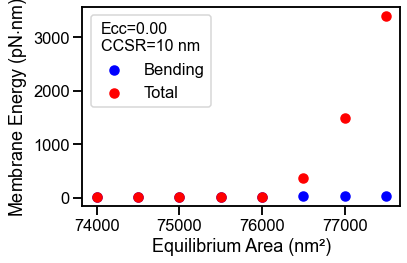

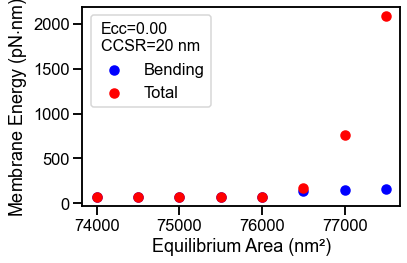

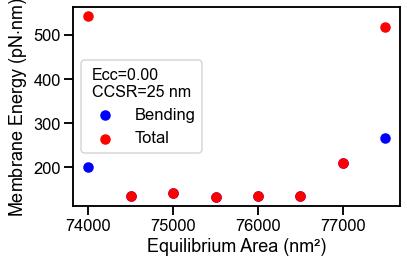

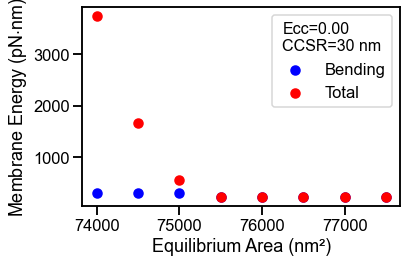

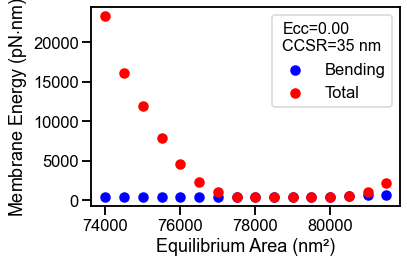

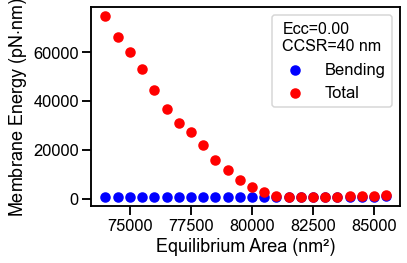

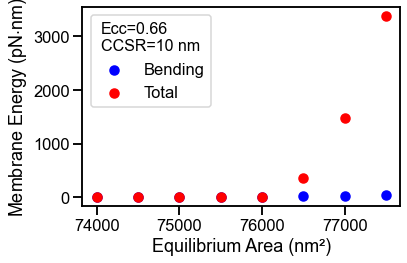

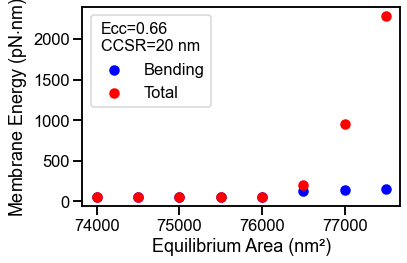

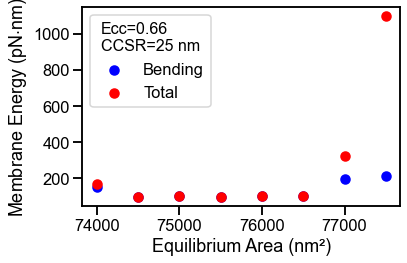

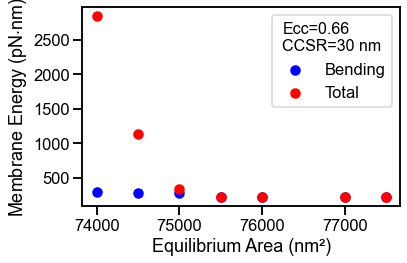

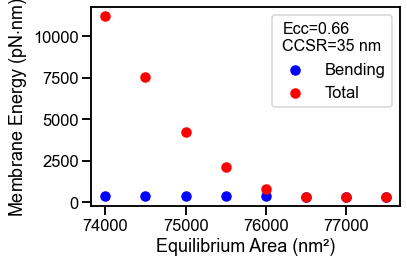

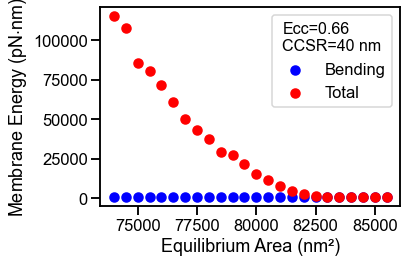

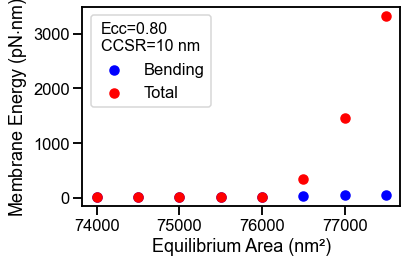

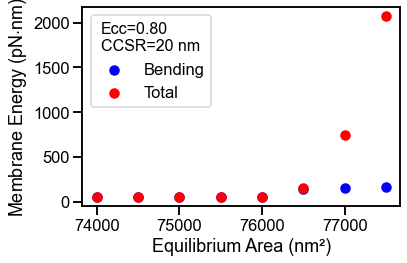

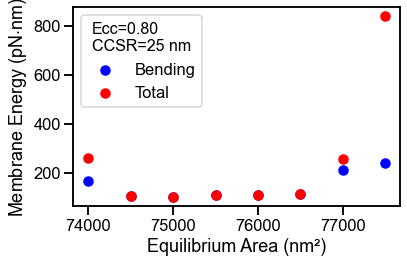

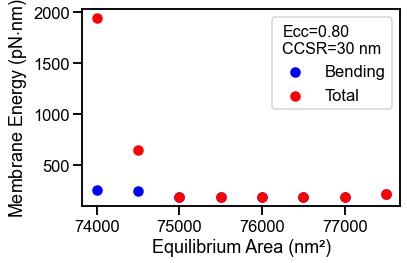

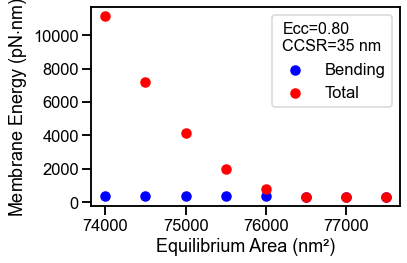

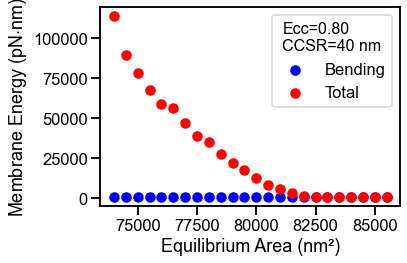

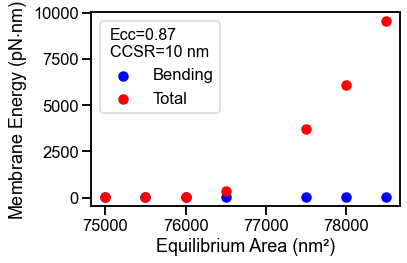

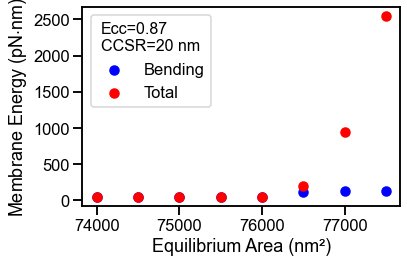

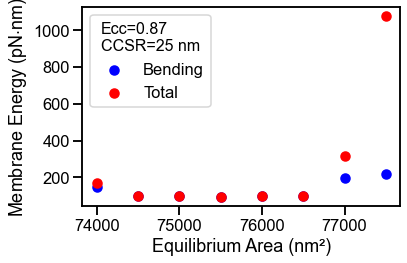

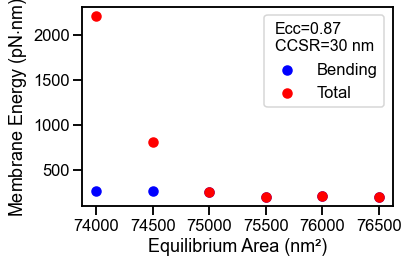

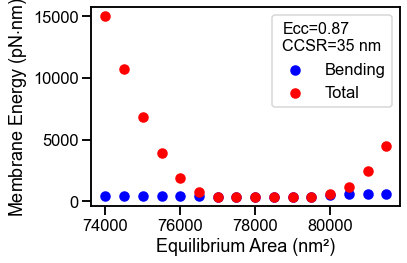

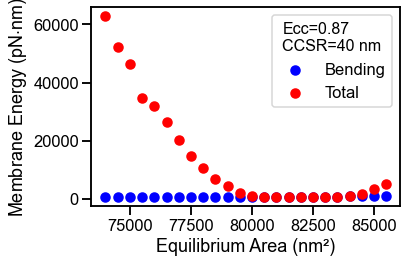

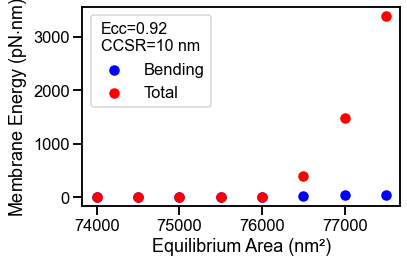

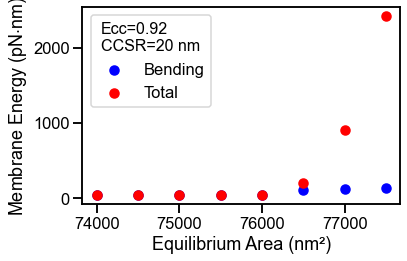

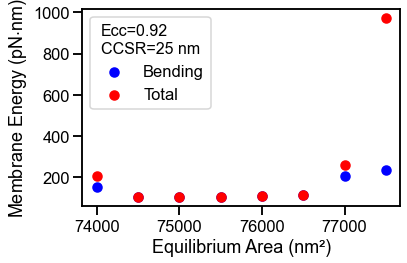

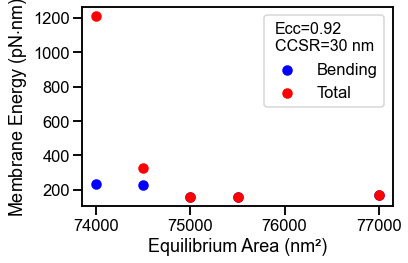

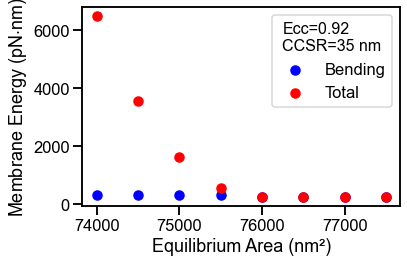

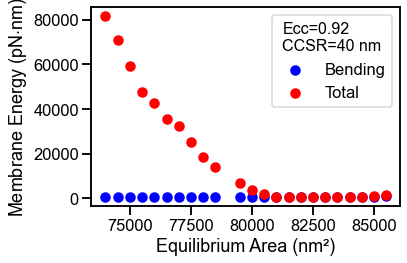

'./svg'

In [28]:
# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Unique trial groups
trial_groups = df_results['TrialGroup'].unique()
size_groups = df_results['SizeGroup'].unique()

# Define superscript format for labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Membrane Energy (pN$\cdot$nm)"

# Generate plots for each trial group
for trial_group, size_group in itertools.product(trial_groups, size_groups):
    df_group = df_results[(df_results['TrialGroup'] == trial_group) & (df_results['SizeGroup'] == size_group)]
    ecc = df_group["Ecc"].iloc[0]

    # Plot EB vs RelaxArea
    plt.figure(figsize=(6, 4))
    plt.scatter(df_group['RelaxArea'], df_group['EB'], color='b',
                label=f'Bending')

    # Plot Etot vs RelaxArea
    plt.scatter(df_group['RelaxArea'], df_group['Etot'], color='r',
                label=f'Total')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(title = f'Ecc={"{:.2f}".format(ecc)}\nCCSR={size_group} nm', title_fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir,
                             f'TrialGroup_{trial_group}_{size_group}_EB_Etot_vs_RelaxArea.svg'), format='svg')
    plt.show()

# Notify user that the plots are saved
output_dir


## 2.2. Generate a grid of subplots for `EB` `EA` `E_tot` versus `S_0`

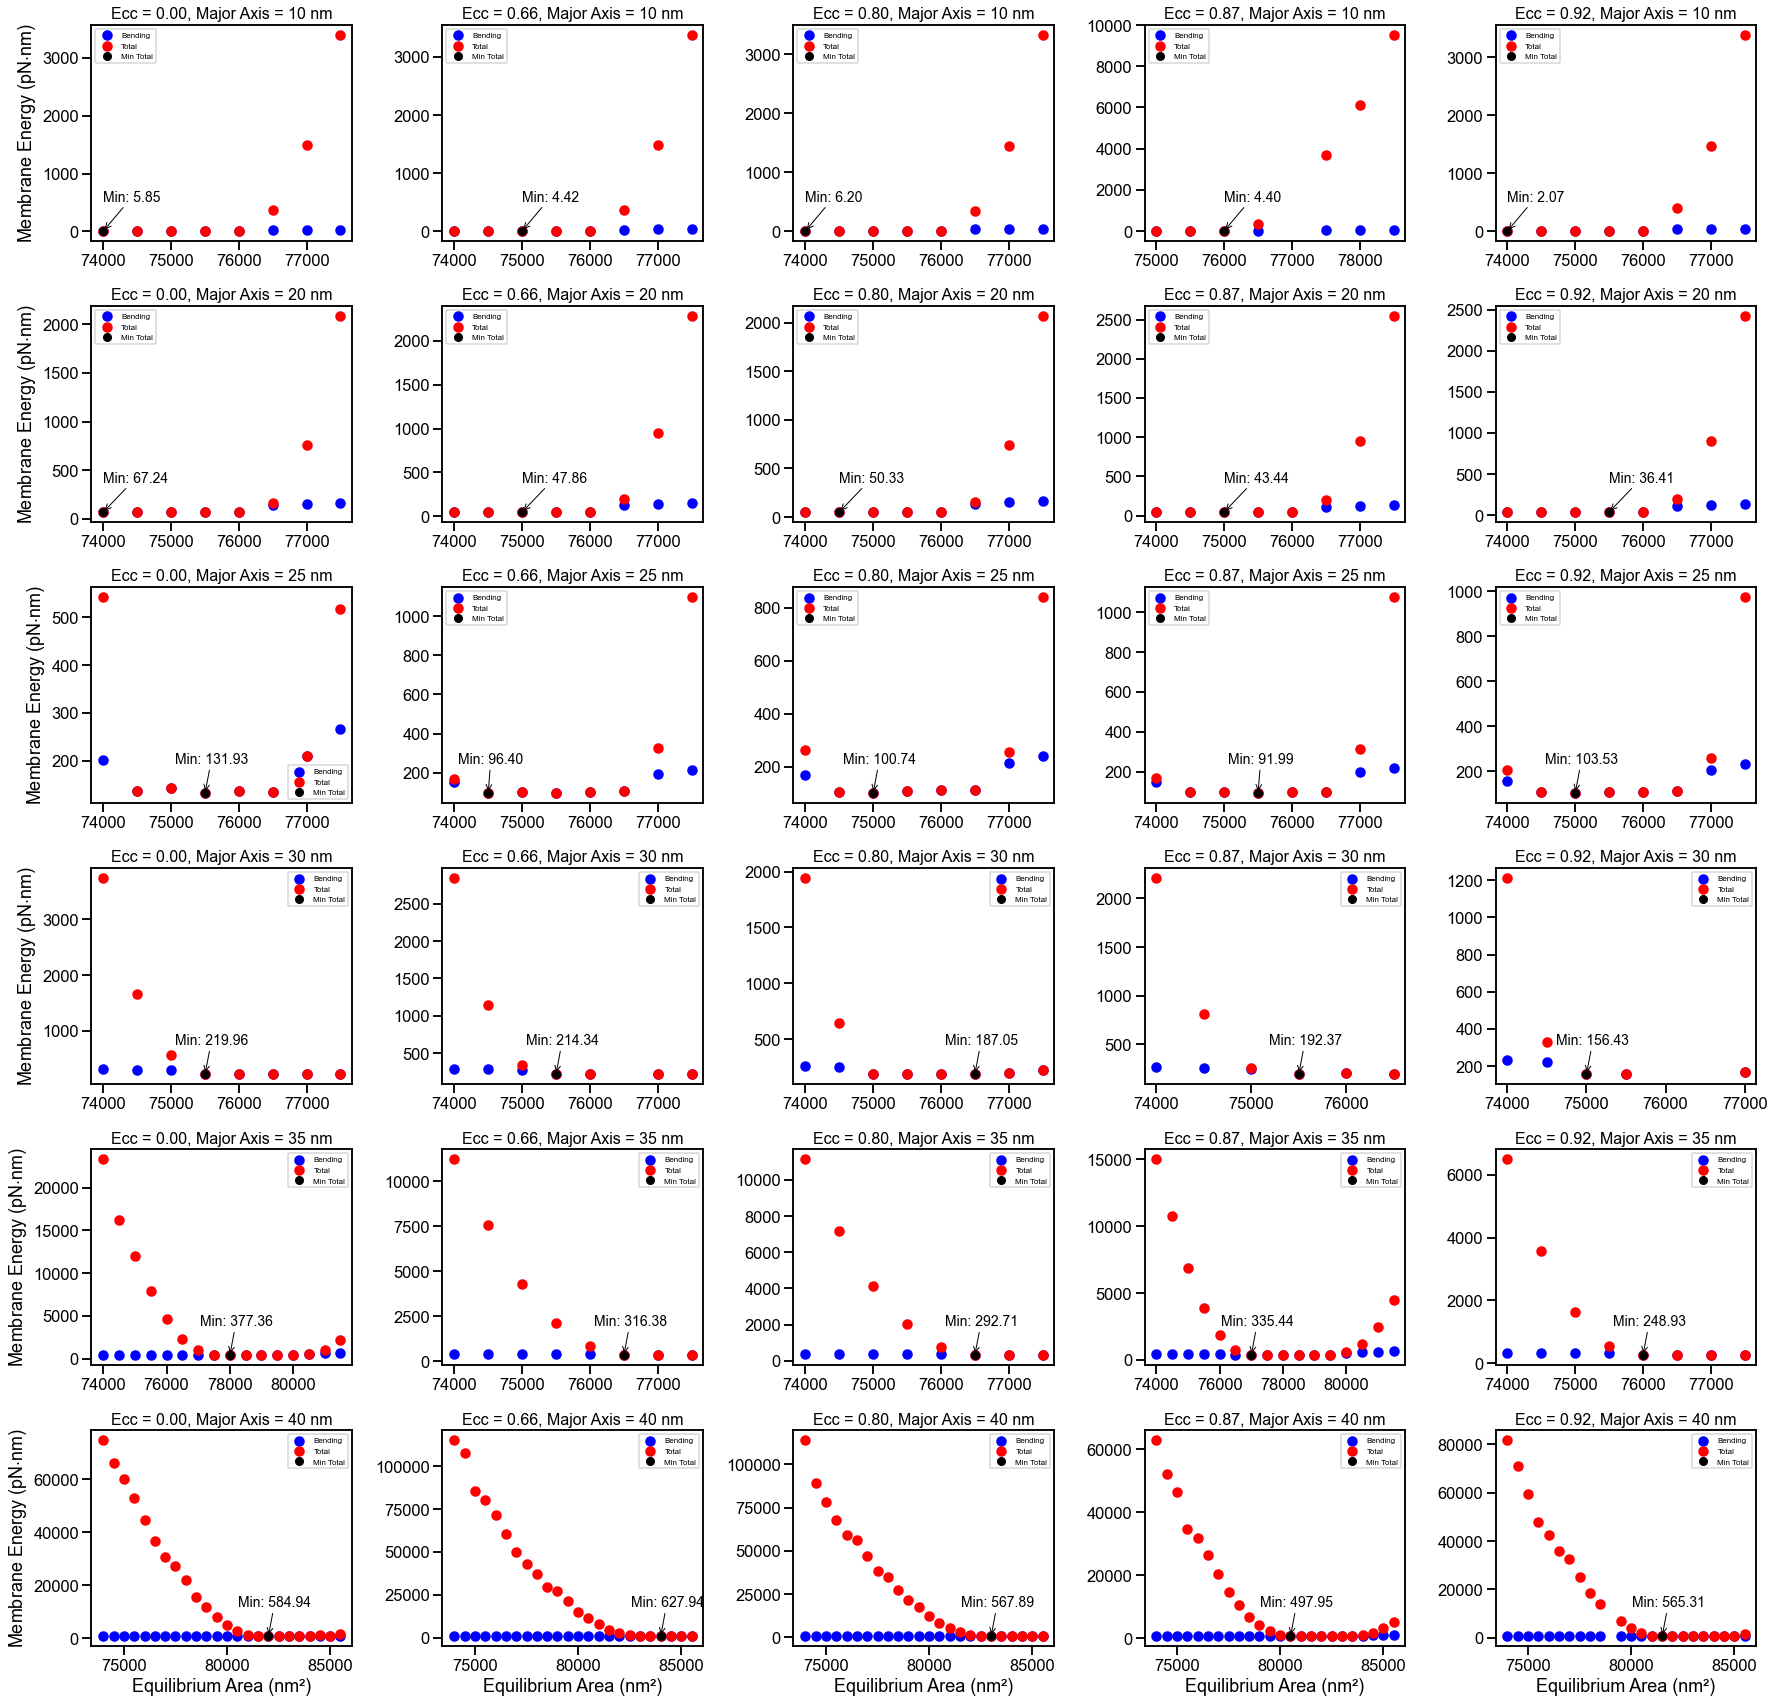

In [29]:
import os
import matplotlib.pyplot as plt
import itertools

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Sort unique groups for consistent subplot arrangement
trial_groups = sorted(df_results['TrialGroup'].unique())   # columns
size_groups = sorted(df_results['SizeGroup'].unique())     # rows

# Define labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Membrane Energy (pN$\cdot$nm)"

# Initialize figure
fig, axes = plt.subplots(len(size_groups), len(trial_groups),
                         figsize=(5 * len(trial_groups), 4 * len(size_groups)),
                         sharex=False, sharey=False)

# Ensure axes is 2D for consistent indexing
if len(size_groups) == 1:
    axes = [axes]
if len(trial_groups) == 1:
    axes = [[ax] for ax in axes]

# Generate plots
for i, size_group in enumerate(size_groups):
    for j, trial_group in enumerate(trial_groups):
        ax = axes[i][j]
        df_group = df_results[(df_results['TrialGroup'] == trial_group) &
                              (df_results['SizeGroup'] == size_group)]

        if df_group.empty:
            ax.set_visible(False)
            continue

        ecc = df_group["Ecc"].iloc[0]

        # Find and highlight minimum total energy
        min_idx = df_group['Etot'].idxmin()
        min_x = df_group.loc[min_idx, 'RelaxArea']
        min_y = df_group.loc[min_idx, 'Etot']

        ax.scatter(df_group['RelaxArea'], df_group['EB'], color='b', label='Bending')
        ax.scatter(df_group['RelaxArea'], df_group['Etot'], color='r', label='Total')
        ax.plot(min_x, min_y, 'ko', markersize=8, label='Min Total')
        
        # place arrow
        xtest = -30
        if size_group <25:
            xtest = 0
        ax.annotate(f"Min: {min_y:.2f}", xy=(min_x, min_y), xytext=(xtest, 30),
                    textcoords='offset points', fontsize=14,
                    arrowprops=dict(arrowstyle="->", lw=1.0))

        ax.set_title(f'Ecc = {ecc:.2f}, Major Axis = {size_group} nm', fontsize=16)
        if j == 0:
            ax.set_ylabel(y_label)
        if i == len(size_groups) - 1:
            ax.set_xlabel(x_label)

        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Grid_EB_Etot_vs_RelaxArea.svg'), format='svg')
plt.show()


## 2.3. Generate a grid of subplots for tension 

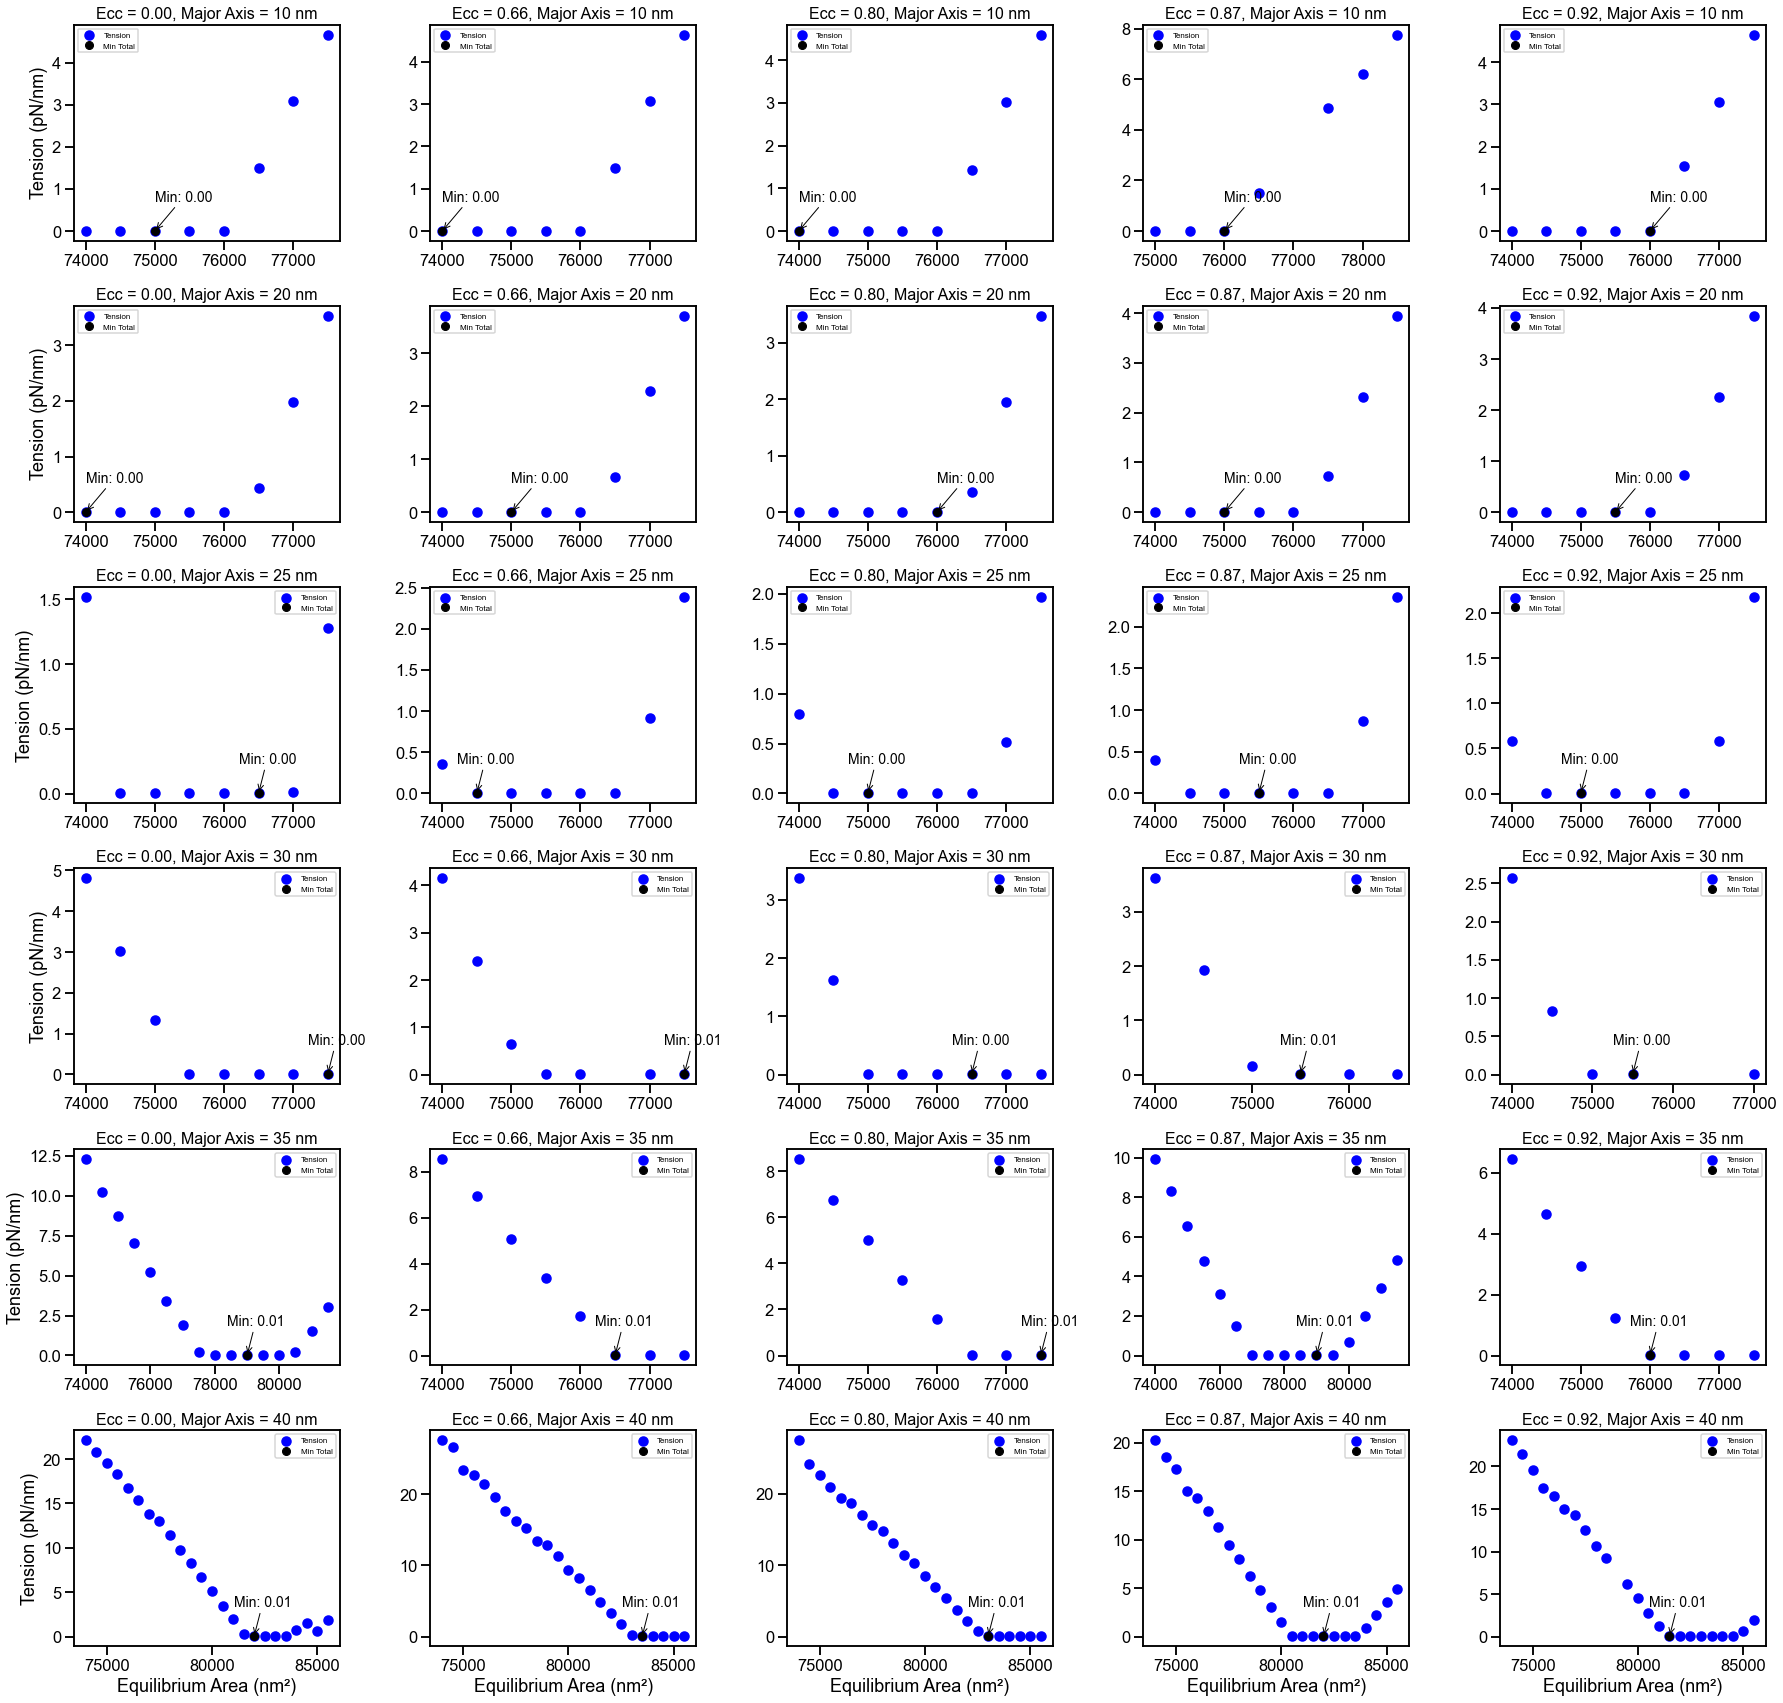

In [30]:
import os
import matplotlib.pyplot as plt
import itertools

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Sort unique groups for consistent subplot arrangement
trial_groups = sorted(df_results['TrialGroup'].unique())   # columns
size_groups = sorted(df_results['SizeGroup'].unique())     # rows

# Define labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Tension (pN/nm)"

# Initialize figure
fig, axes = plt.subplots(len(size_groups), len(trial_groups),
                         figsize=(5 * len(trial_groups), 4 * len(size_groups)),
                         sharex=False, sharey=False)

# Ensure axes is 2D for consistent indexing
if len(size_groups) == 1:
    axes = [axes]
if len(trial_groups) == 1:
    axes = [[ax] for ax in axes]
    
# Generate plots
for i, size_group in enumerate(size_groups):
    for j, trial_group in enumerate(trial_groups):
        ax = axes[i][j]
        df_group = df_results[(df_results['TrialGroup'] == trial_group) &
                              (df_results['SizeGroup'] == size_group)]

        if df_group.empty:
            ax.set_visible(False)
            continue

        ecc = df_group["Ecc"].iloc[0]

        # Find and highlight minimum total energy
        min_idx = df_group['Tension'].idxmin()
        min_x = df_group.loc[min_idx, 'RelaxArea']
        min_y = df_group.loc[min_idx, 'Tension']

        ax.scatter(df_group['RelaxArea'], df_group['Tension'], color='b', label='Tension')
        ax.plot(min_x, min_y, 'ko', markersize=8, label='Min Total')
        
        # place arrow
        xtest = -20
        if size_group <25:
            xtest = 0
        ax.annotate(f"Min: {min_y:.2f}", xy=(min_x, min_y), xytext=(xtest, 30),
                    textcoords='offset points', fontsize=14,
                    arrowprops=dict(arrowstyle="->", lw=1.0))

        ax.set_title(f'Ecc = {ecc:.2f}, Major Axis = {size_group} nm', fontsize=16)
        if j == 0:
            ax.set_ylabel(y_label)
        if i == len(size_groups) - 1:
            ax.set_xlabel(x_label)

        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Grid_tension_vs_RelaxArea.svg'), format='svg')
plt.show()


## 2.4. Generate a grid of subplots for tension < 0.04 pN/nm

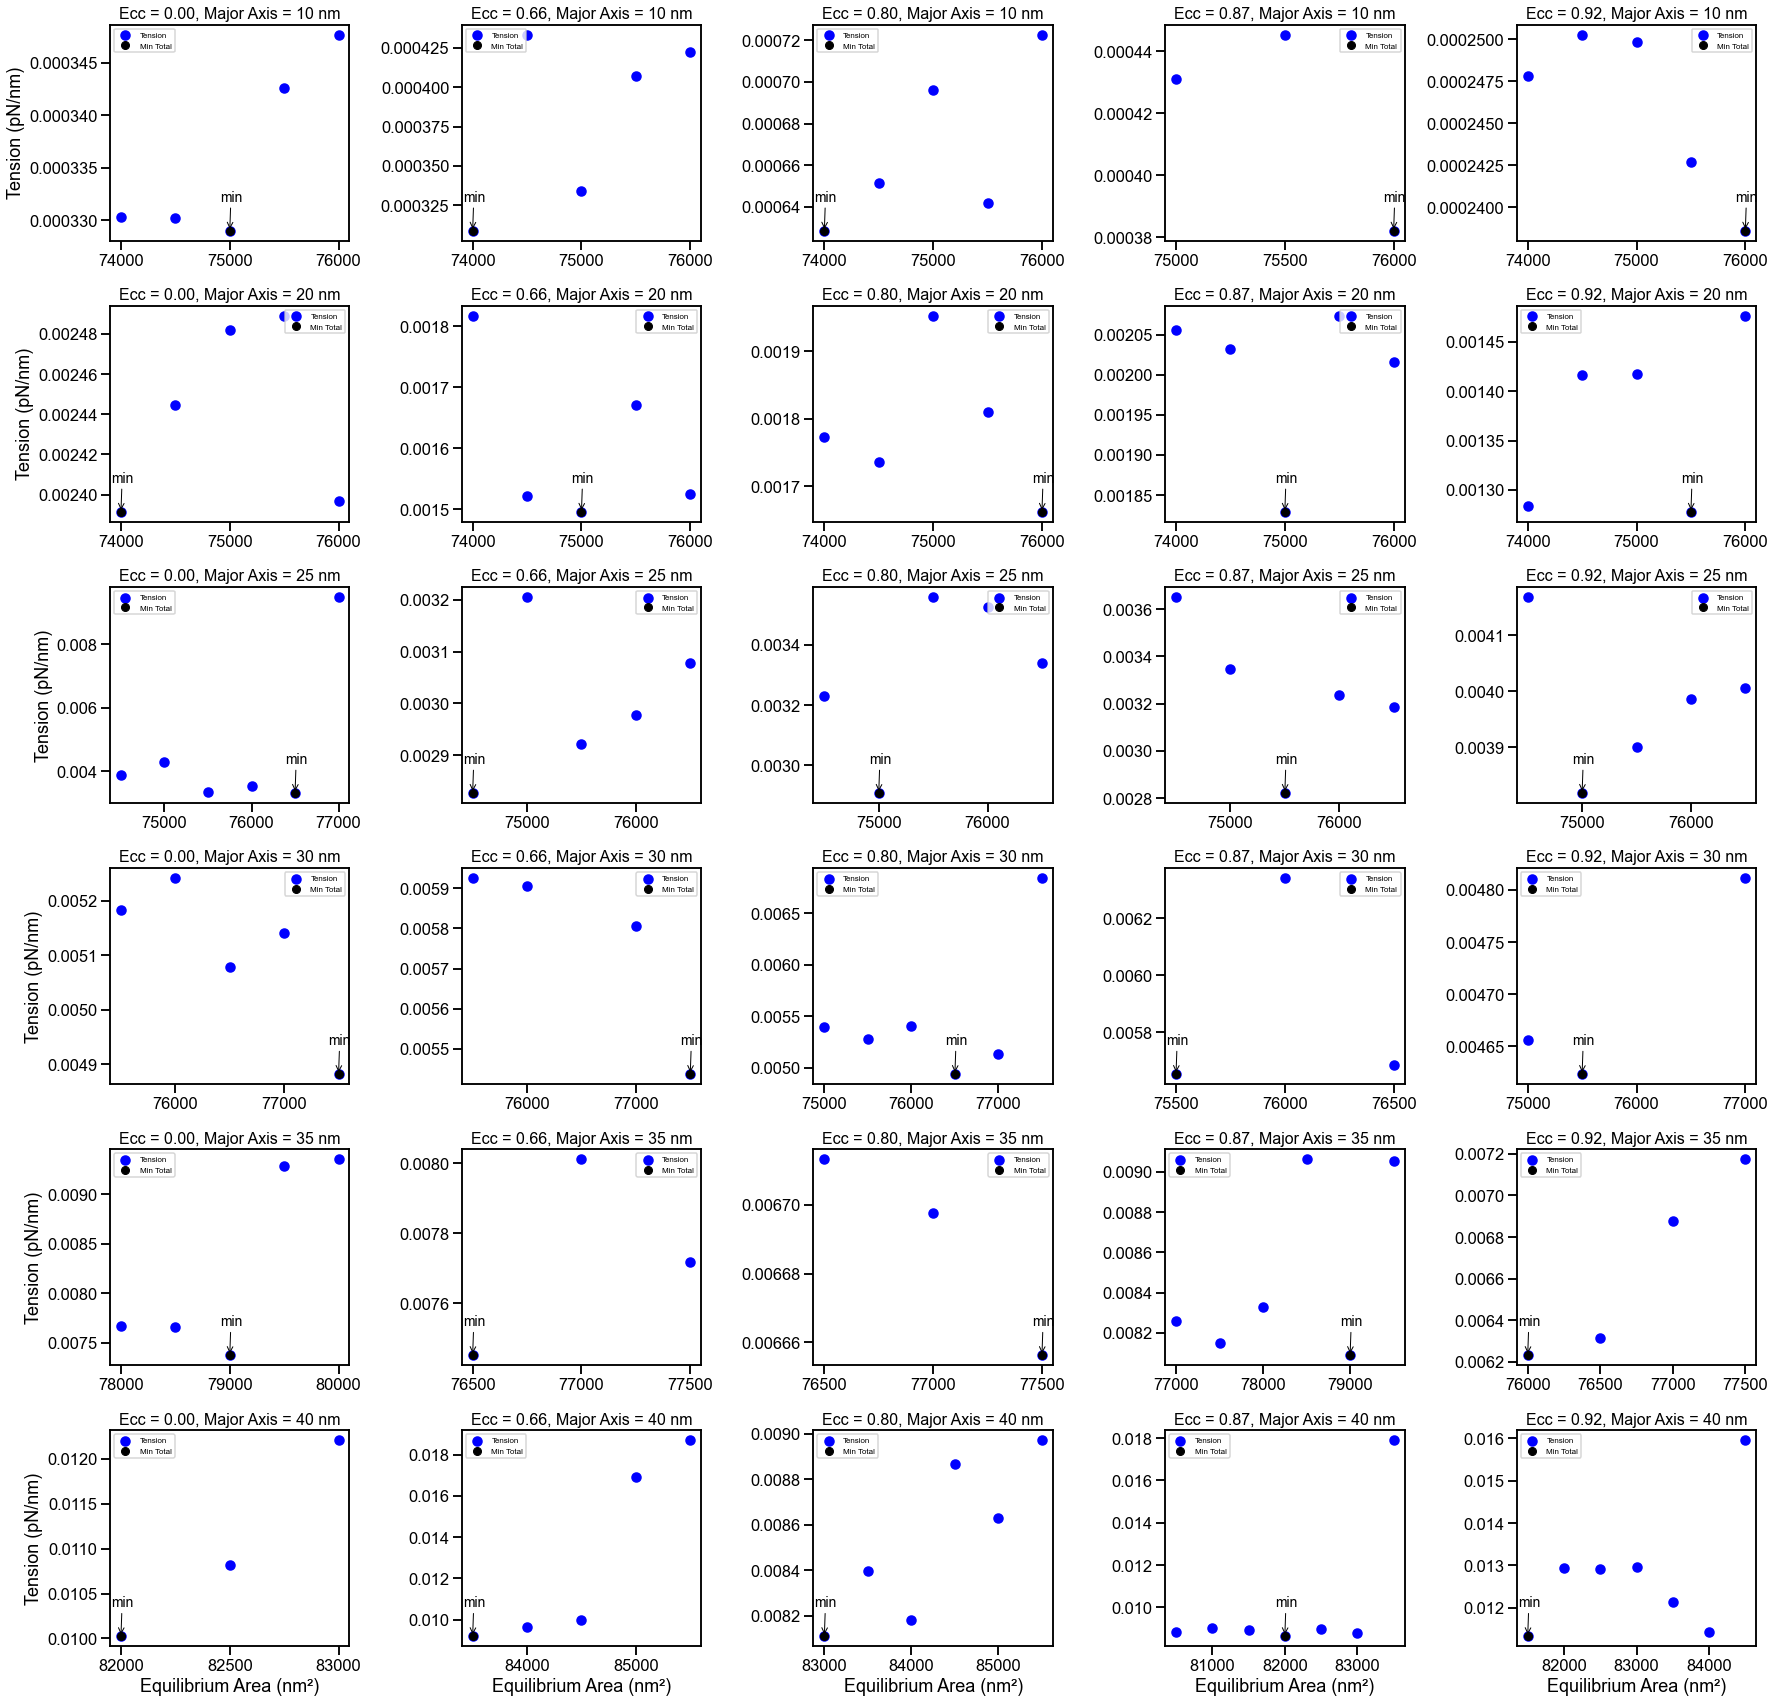

In [31]:
import os
import matplotlib.pyplot as plt
import itertools

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Sort unique groups for consistent subplot arrangement
trial_groups = sorted(df_results['TrialGroup'].unique())   # columns
size_groups = sorted(df_results['SizeGroup'].unique())     # rows

# Define labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Tension (pN/nm)"

# Initialize figure
fig, axes = plt.subplots(len(size_groups), len(trial_groups),
                         figsize=(5 * len(trial_groups), 4 * len(size_groups)),
                         sharex=False, sharey=False)

# Ensure axes is 2D for consistent indexing
if len(size_groups) == 1:
    axes = [axes]
if len(trial_groups) == 1:
    axes = [[ax] for ax in axes]
    
# Generate plots
for i, size_group in enumerate(size_groups):
    for j, trial_group in enumerate(trial_groups):
        ax = axes[i][j]
        df_group = df_results[(df_results['TrialGroup'] == trial_group) &
                              (df_results['SizeGroup'] == size_group)]

        if df_group.empty:
            ax.set_visible(False)
            continue

        ecc = df_group["Ecc"].iloc[0]

        # Find and highlight minimum total energy
        min_idx = df_group['Tension'].idxmin()
        min_x = df_group.loc[min_idx, 'RelaxArea']
        min_y = df_group.loc[min_idx, 'Tension']

        ax.scatter(df_group[df_group['Tension'] < 0.04]['RelaxArea'], df_group[df_group['Tension'] < 0.04]['Tension'], color='b', label='Tension')
        ax.plot(min_x, min_y, 'ko', markersize=8, label='Min Total')
        
        # place arrow
        xtest = -10
        ax.annotate(f"min", xy=(min_x, min_y), xytext=(xtest, 30),
                    textcoords='offset points', fontsize=14,
                    arrowprops=dict(arrowstyle="->", lw=1.0))

        ax.set_title(f'Ecc = {ecc:.2f}, Major Axis = {size_group} nm', fontsize=16)
        if j == 0:
            ax.set_ylabel(y_label)
        if i == len(size_groups) - 1:
            ax.set_xlabel(x_label)

        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Grid_tension_0.04_vs_RelaxArea.svg'), format='svg')
plt.show()


## 2.5. Generate a grid of subplots for tension < 0.04 pN/nm versus Etot

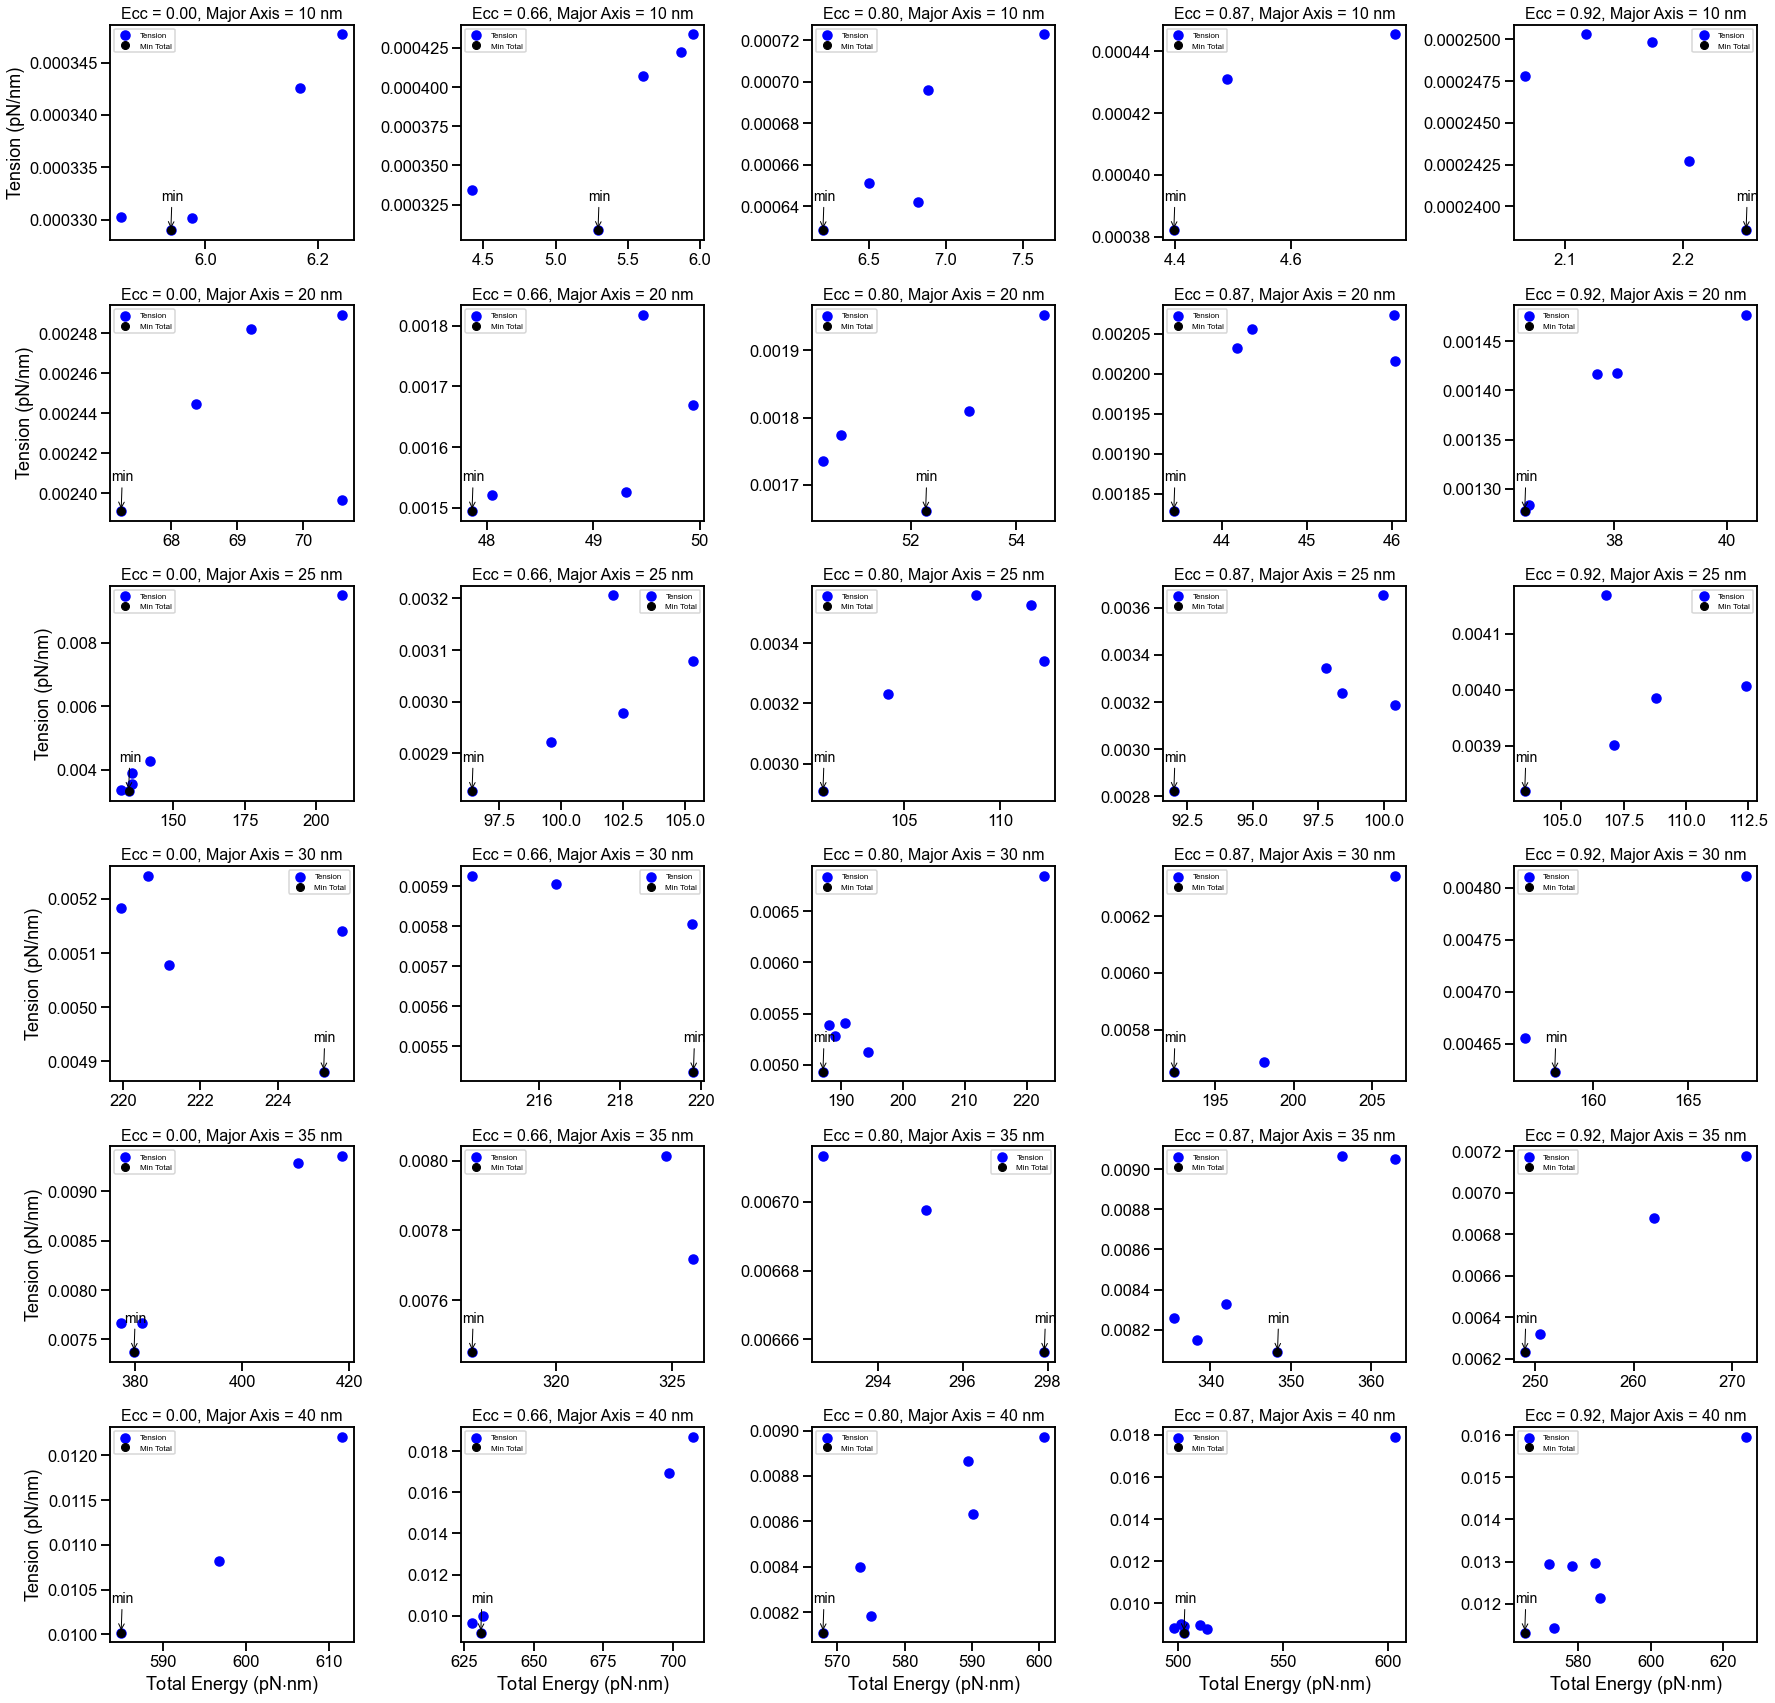

In [32]:
import os
import matplotlib.pyplot as plt
import itertools

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Sort unique groups for consistent subplot arrangement
trial_groups = sorted(df_results['TrialGroup'].unique())   # columns
size_groups = sorted(df_results['SizeGroup'].unique())     # rows

# Define labels
x_label = r"Total Energy (pN$\cdot$nm)"
y_label = r"Tension (pN/nm)"

# Initialize figure
fig, axes = plt.subplots(len(size_groups), len(trial_groups),
                         figsize=(5 * len(trial_groups), 4 * len(size_groups)),
                         sharex=False, sharey=False)

# Ensure axes is 2D for consistent indexing
if len(size_groups) == 1:
    axes = [axes]
if len(trial_groups) == 1:
    axes = [[ax] for ax in axes]
    
# Generate plots
for i, size_group in enumerate(size_groups):
    for j, trial_group in enumerate(trial_groups):
        ax = axes[i][j]
        df_group = df_results[(df_results['TrialGroup'] == trial_group) &
                              (df_results['SizeGroup'] == size_group)]

        if df_group.empty:
            ax.set_visible(False)
            continue

        ecc = df_group["Ecc"].iloc[0]

        # Find and highlight minimum total energy
        min_idx = df_group['Tension'].idxmin()
        min_x = df_group.loc[min_idx, 'Etot']
        min_y = df_group.loc[min_idx, 'Tension']

        ax.scatter(df_group[df_group['Tension'] < 0.04]['Etot'], df_group[df_group['Tension'] < 0.04]['Tension'], color='b', label='Tension')
        ax.plot(min_x, min_y, 'ko', markersize=8, label='Min Total')
        
        # place arrow
        xtest = -10
        ax.annotate(f"min", xy=(min_x, min_y), xytext=(xtest, 30),
                    textcoords='offset points', fontsize=14,
                    arrowprops=dict(arrowstyle="->", lw=1.0))

        ax.set_title(f'Ecc = {ecc:.2f}, Major Axis = {size_group} nm', fontsize=16)
        if j == 0:
            ax.set_ylabel(y_label)
        if i == len(size_groups) - 1:
            ax.set_xlabel(x_label)

        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Grid_tension_0.04_vs_Etot.svg'), format='svg')
plt.show()


## 2.6. Generate a grid of subplots for tension versus Etot

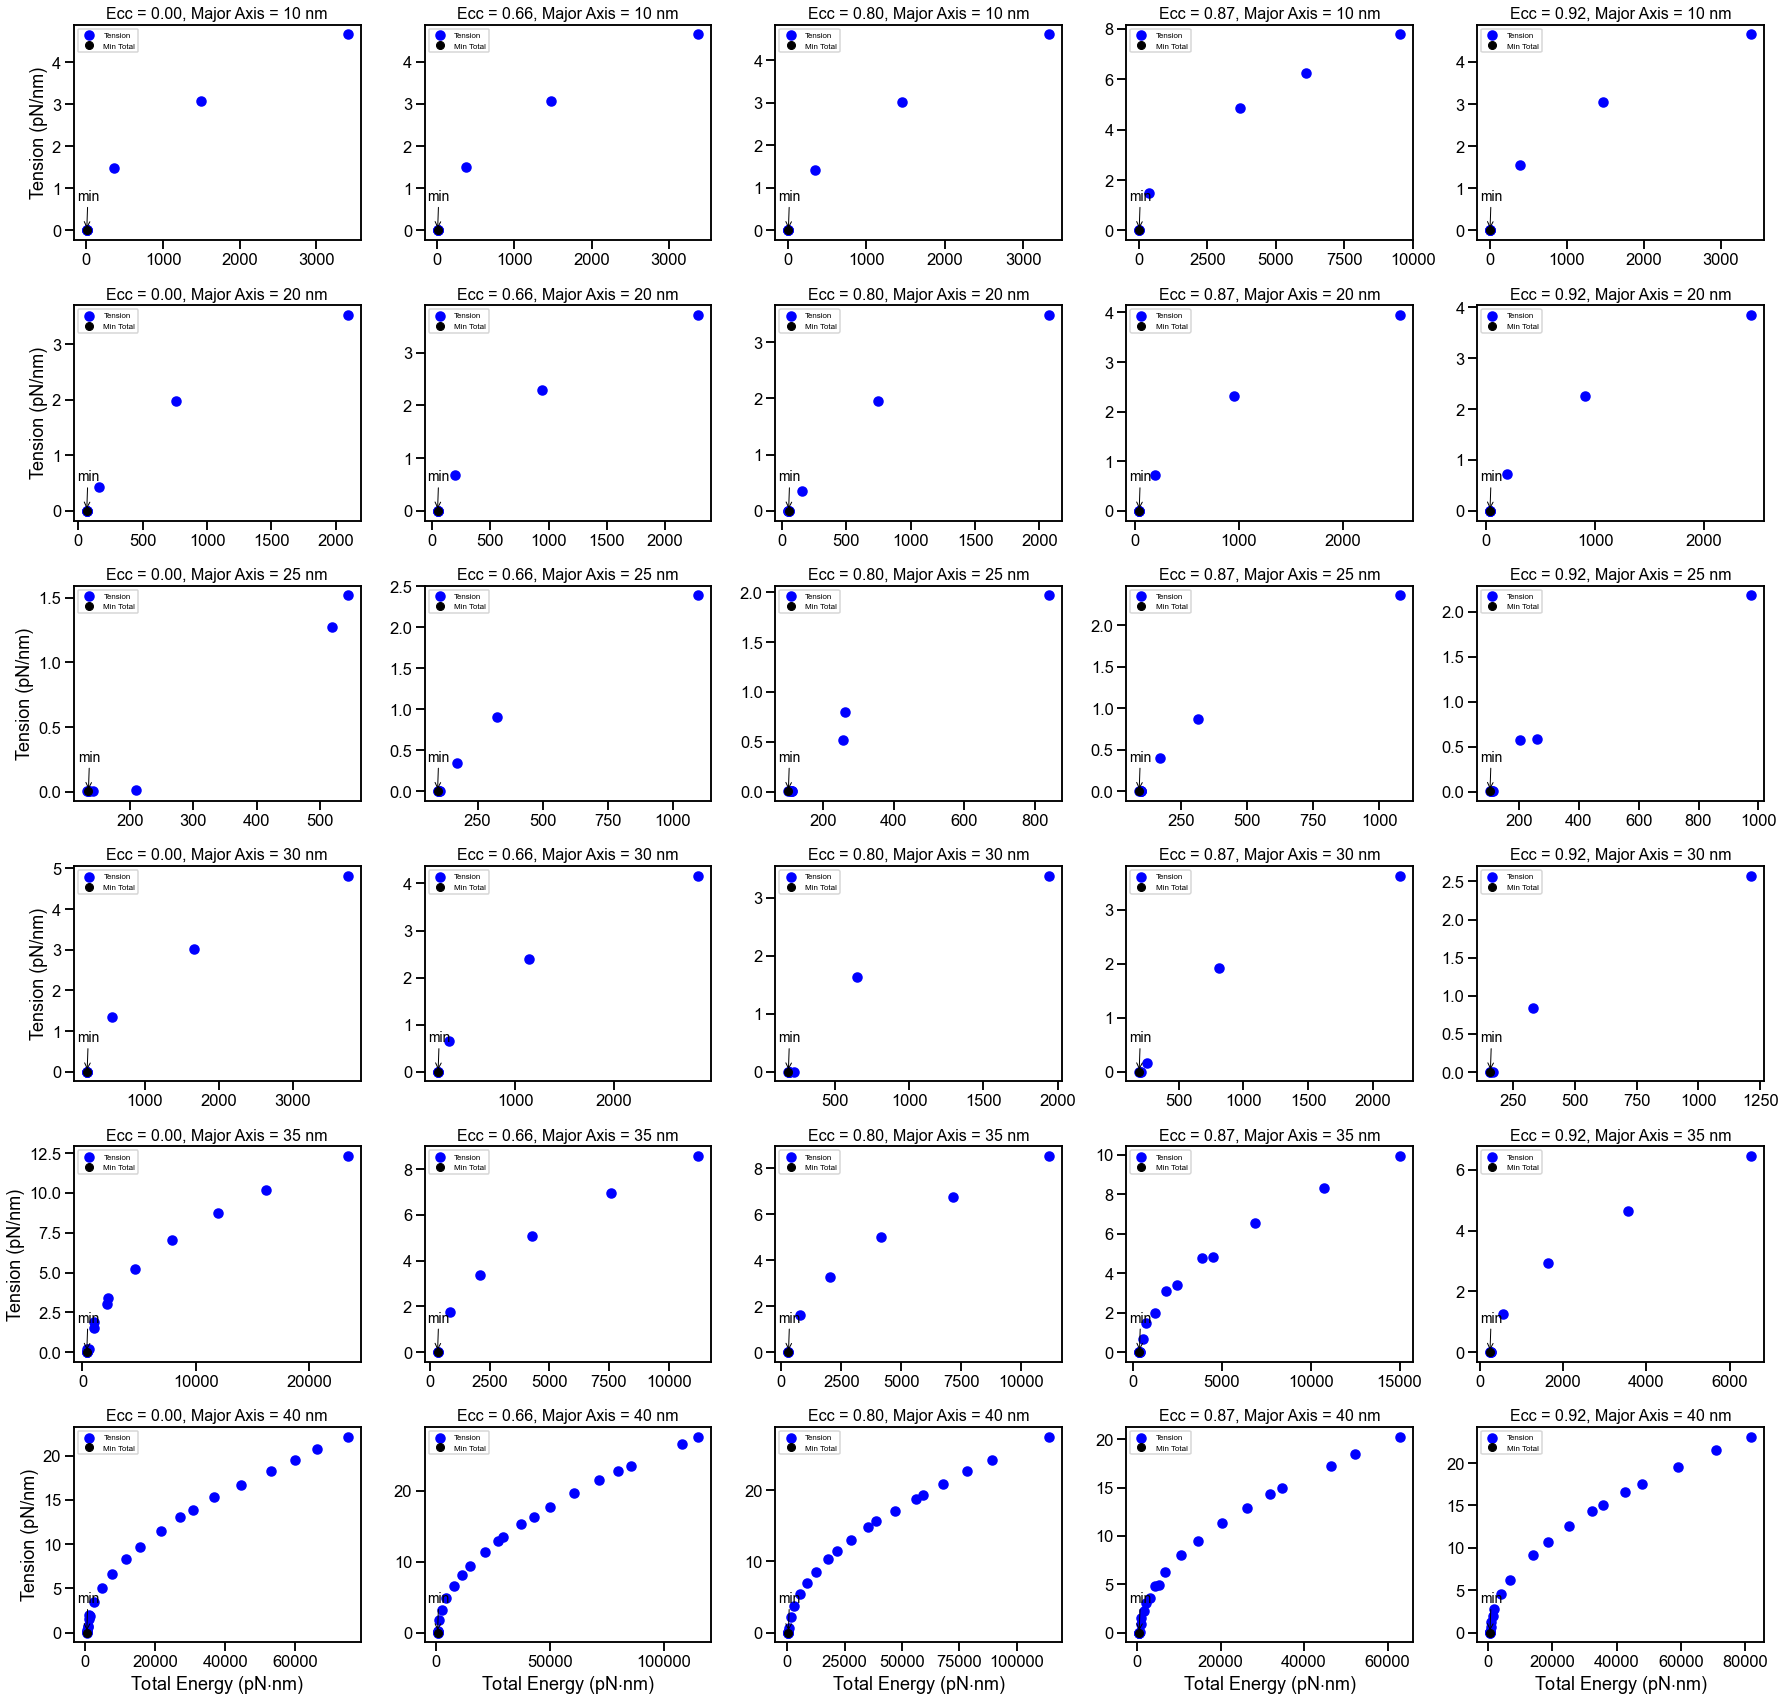

In [33]:
import os
import matplotlib.pyplot as plt
import itertools

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Sort unique groups for consistent subplot arrangement
trial_groups = sorted(df_results['TrialGroup'].unique())   # columns
size_groups = sorted(df_results['SizeGroup'].unique())     # rows

# Define labels
x_label = r"Total Energy (pN$\cdot$nm)"
y_label = r"Tension (pN/nm)"

# Initialize figure
fig, axes = plt.subplots(len(size_groups), len(trial_groups),
                         figsize=(5 * len(trial_groups), 4 * len(size_groups)),
                         sharex=False, sharey=False)

# Ensure axes is 2D for consistent indexing
if len(size_groups) == 1:
    axes = [axes]
if len(trial_groups) == 1:
    axes = [[ax] for ax in axes]
    
# Generate plots
for i, size_group in enumerate(size_groups):
    for j, trial_group in enumerate(trial_groups):
        ax = axes[i][j]
        df_group = df_results[(df_results['TrialGroup'] == trial_group) &
                              (df_results['SizeGroup'] == size_group)]

        if df_group.empty:
            ax.set_visible(False)
            continue

        ecc = df_group["Ecc"].iloc[0]

        # Find and highlight minimum total energy
        min_idx = df_group['Tension'].idxmin()
        min_x = df_group.loc[min_idx, 'Etot']
        min_y = df_group.loc[min_idx, 'Tension']

        ax.scatter(df_group['Etot'], df_group['Tension'], color='b', label='Tension')
        ax.plot(min_x, min_y, 'ko', markersize=8, label='Min Total')
        
        # place arrow
        xtest = -10
        ax.annotate(f"min", xy=(min_x, min_y), xytext=(xtest, 30),
                    textcoords='offset points', fontsize=14,
                    arrowprops=dict(arrowstyle="->", lw=1.0))

        ax.set_title(f'Ecc = {ecc:.2f}, Major Axis = {size_group} nm', fontsize=16)
        if j == 0:
            ax.set_ylabel(y_label)
        if i == len(size_groups) - 1:
            ax.set_xlabel(x_label)

        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Grid_tension_vs_Etot.svg'), format='svg')
plt.show()


## 2.7. Generate a grid of subplots for heights

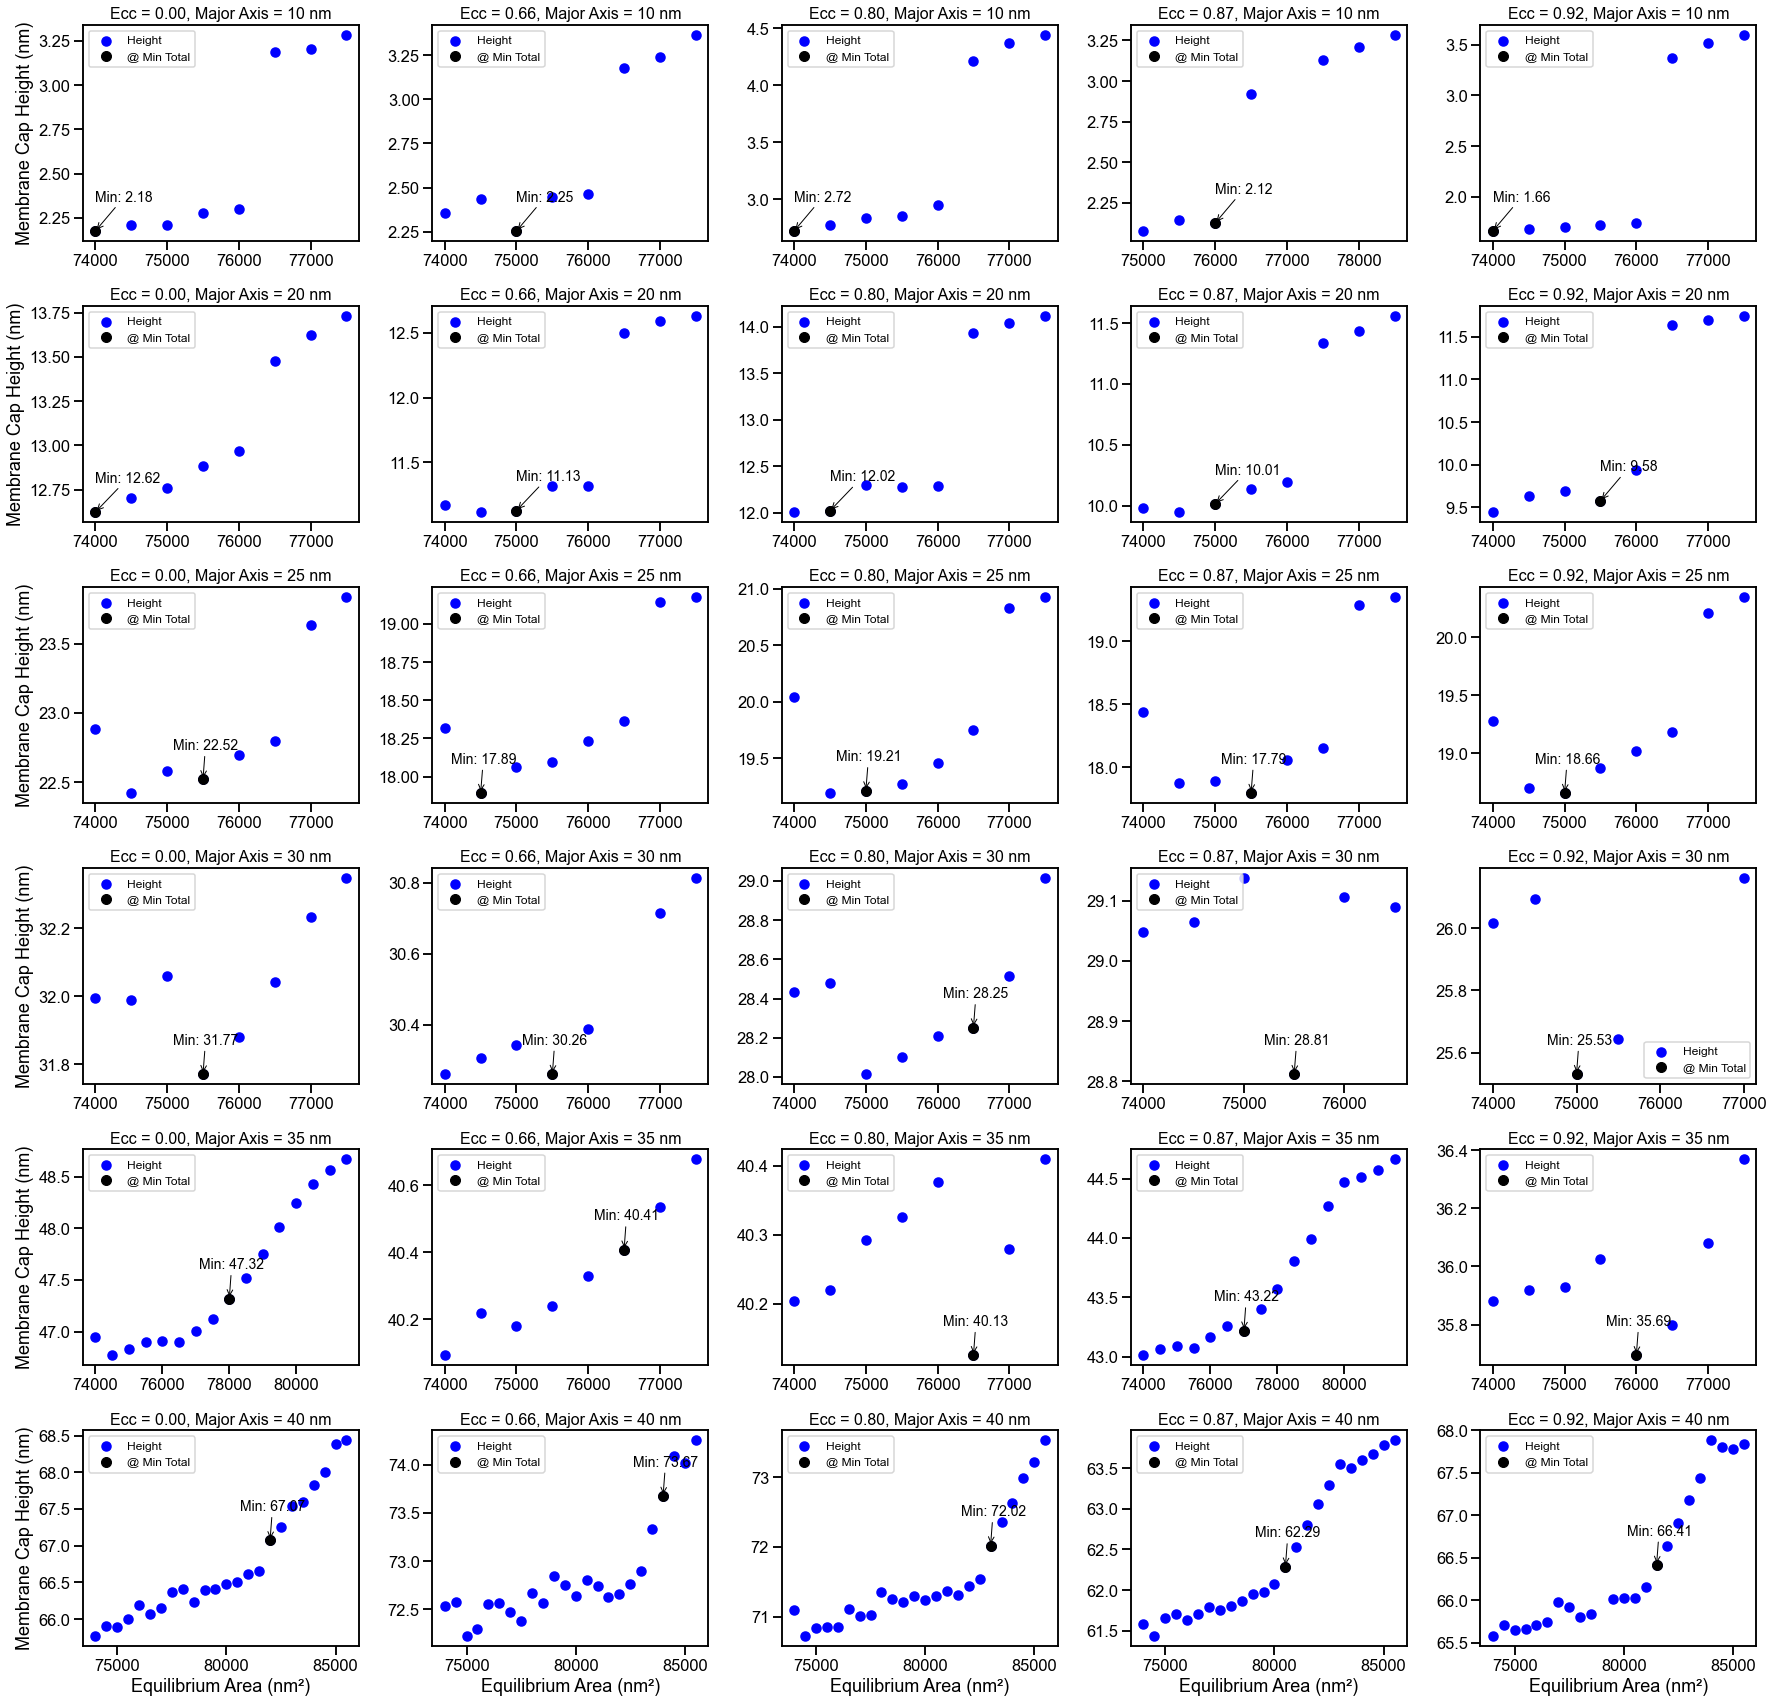

In [34]:
import os
import matplotlib.pyplot as plt
import itertools

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Sort unique groups for consistent subplot arrangement
trial_groups = sorted(df_results['TrialGroup'].unique())   # columns
size_groups = sorted(df_results['SizeGroup'].unique())     # rows

# Define labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Membrane Cap Height (nm)"

# Initialize figure
fig, axes = plt.subplots(len(size_groups), len(trial_groups),
                         figsize=(5 * len(trial_groups), 4 * len(size_groups)),
                         sharex=False, sharey=False)

# Ensure axes is 2D for consistent indexing
if len(size_groups) == 1:
    axes = [axes]
if len(trial_groups) == 1:
    axes = [[ax] for ax in axes]

# Generate plots
for i, size_group in enumerate(size_groups):
    for j, trial_group in enumerate(trial_groups):
        ax = axes[i][j]
        df_group = df_results[(df_results['TrialGroup'] == trial_group) &
                              (df_results['SizeGroup'] == size_group)]

        if df_group.empty:
            ax.set_visible(False)
            continue

        ecc = df_group["Ecc"].iloc[0]

        # Find and highlight minimum total energy
        min_idx = df_group['Etot'].idxmin()
        min_x = df_group.loc[min_idx, 'RelaxArea']
        min_y = df_group.loc[min_idx, 'Height']

        ax.scatter(df_group['RelaxArea'], df_group['Height'], color='b', label='Height')
        ax.plot(min_x, min_y, 'ko', markersize=10, label='@ Min Total')
        
        # place arrow
        xtest = -30
        if size_group <25:
            xtest = 0
        ax.annotate(f"Min: {min_y:.2f}", xy=(min_x, min_y), xytext=(xtest, 30),
                    textcoords='offset points', fontsize=14,
                    arrowprops=dict(arrowstyle="->", lw=1.0))

        ax.set_title(f'Ecc = {ecc:.2f}, Major Axis = {size_group} nm', fontsize=16)
        if j == 0:
            ax.set_ylabel(y_label)
        if i == len(size_groups) - 1:
            ax.set_xlabel(x_label)

        ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Grid_Height_vs_RelaxArea.svg'), format='svg')
plt.show()


## 2.8 Height vs Ngags by eccentricity

- Renormalized x-axis, it might collapse again
- Add as an additional plot to the results section
- @todo put on error bars

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_71840/995934964.py:38: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


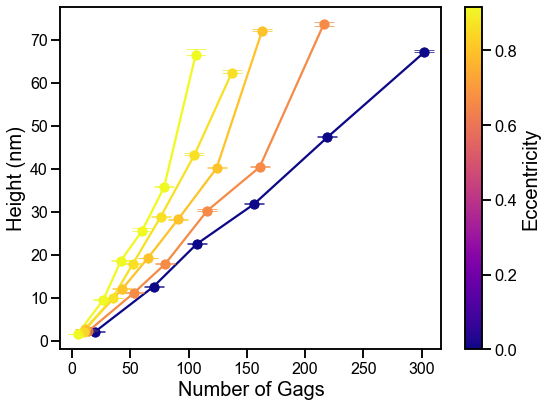

In [40]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    plt.plot(subset['Ngags'], subset['Height'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ngags'], subset['Height'],
                 yerr=[subset['Height'] - subset['height_err_l'], subset['height_err_u']-subset['Height']], 
                 fmt='o', capsize=10, color=cmap(norm(ecc)), alpha=0.7)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Height (nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Height_vs_Ngags_by_Ecc.svg'), format='svg')

plt.show()


# 3. Plot `E_tot` vs `Ngags` by eccentricity

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_71840/887962367.py:37: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


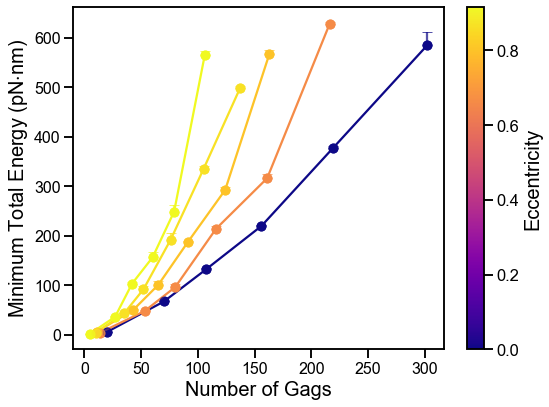

In [20]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    plt.plot(subset['Ngags'], subset['Etot'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ngags'], subset['Etot'], yerr=[np.zeros_like(subset['Etot_err']), subset['Etot_err']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=0.7)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Etot_vs_Ngags_by_Ecc.svg'), format='svg')

plt.show()


0.0
0.66143782776
0.8
0.86602540378
0.91651513899


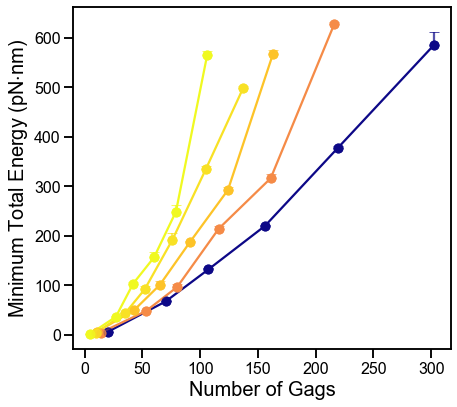

In [21]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(6.7, 6))

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    plt.plot(subset['Ngags'], subset['Etot'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ngags'], subset['Etot'], yerr=[np.zeros_like(subset['Etot_err']), subset['Etot_err']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=0.7)

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Etot_vs_Ngags_by_Ecc_no_cbar.svg'), format='svg')

plt.show()


# 4. Plot `EB` vs `Ngags` by eccentricity

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_71840/2277453192.py:38: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


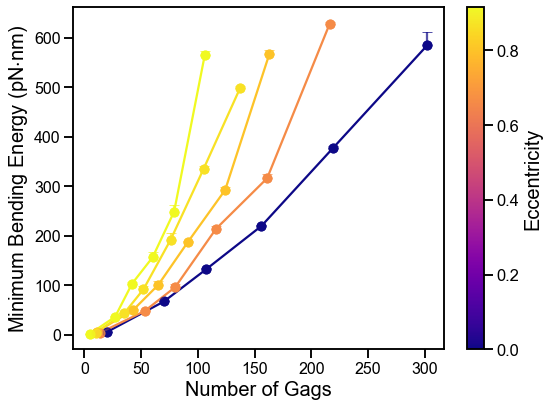

In [22]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    plt.plot(subset['Ngags'], subset['EB'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ngags'], subset['EB'],
                 yerr=[subset['EB'] - subset['EB_err_l'], subset['EB_err_u'] - subset['EB']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=0.7)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_Ngags_by_Ecc.svg'), format='svg')

plt.show()


# 6. Plot smallest possible circumscribing spherical sector radius

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_71840/4294863444.py:38: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


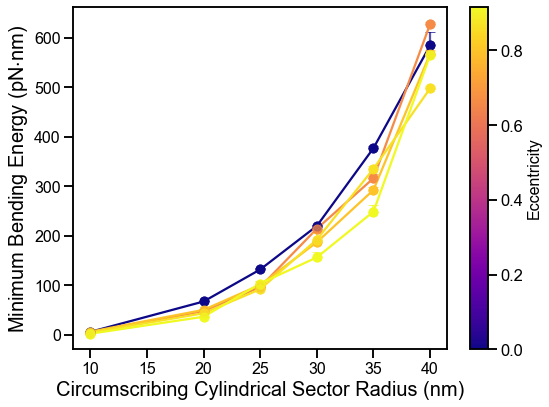

In [23]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    plt.plot(subset['SizeGroup'], subset['EB'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['SizeGroup'], subset['EB'],
                 yerr=[subset['EB'] - subset['EB_err_l'], subset['EB_err_u'] - subset['EB']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=0.7)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Eccentricity", fontsize=16, fontname='Arial')

# Labels and title
plt.xlabel("Circumscribing Cylindrical Sector Radius (nm)", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_CCSR_by_Ecc_with_SGA_theory_lineplot.svg'), format='svg')

plt.show()


## 6.1. Add a theoretical curve with small gradient approximation (SGA) to circumscribing cylindrical sector radius plot

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_95008/642611539.py:74: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


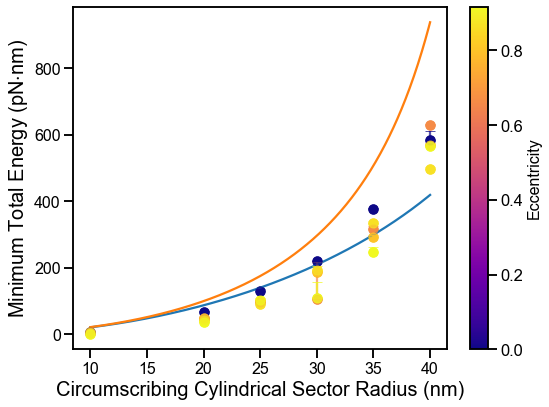

In [54]:
theory_radius = np.linspace(10, 40, 500)

def theory_function_eb(theory_radius, membrane_cap_spherical_radius = 59.0,
                       gag_cap_spherical_radius = 50.0, kappa = 83.4, rho_R = 135.0):
    """
    Note : small gradient approximation applied
    
    eb theory = 4h /r * pi * kappa = 4 (r - sqrt(r^2 - rho^2)) / r * pi * kappa
    
    eb relax = 8πκ tan^2⁡θ  (ρ_M^2)/(ρ_R^2-ρ_M^2 )
    """
    r = gag_cap_spherical_radius
    rho = theory_radius
    
    eb_cap = 4 * (r - np.sqrt(r**2 - rho**2)) / r * np.pi * kappa
    
    # Add relaxation
    
    tan_theta = theory_radius / np.sqrt(r ** 2 - rho ** 2)
    
    # Use similar triangles to scale up rho to rho_M
    
    rho_M = rho / gag_cap_spherical_radius * membrane_cap_spherical_radius
    
    # Use equation to calculate relaxation energy
    
    eb_relax = 8 * np.pi * kappa * (tan_theta ** 2) * (rho_M ** 2) / (rho_R ** 2 - rho_M ** 2)
    
    return eb_cap, (eb_cap + eb_relax)

theory_eb, theory_eb_add_relax  = theory_function_eb(theory_radius)

"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot theory curves
plt.plot(theory_radius, theory_eb)
plt.plot(theory_radius, theory_eb_add_relax)

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    plt.scatter(subset['SizeGroup'], subset['Etot'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['SizeGroup'], subset['Etot'],
                 yerr=[np.zeros(len(subset['Etot_err'])), subset['Etot_err']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=0.7)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Eccentricity", fontsize=16, fontname='Arial')

# Labels and title
plt.xlabel("Circumscribing Cylindrical Sector Radius (nm)", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Etot_vs_CCSR_by_Ecc_with_SGA_theory.svg'), format='svg')

plt.show()


## 6.2. Calculate a no SGA theoretical curve with methods in solve_membrane_shape_bvp_wo_SGA.ipynb

### Note!! The code takes ~15 min to run (on a M1 chip MacOX), load the `.npy` file if no rerun needed

### 6.2.1. Define the functions

In [27]:
from scipy.integrate import solve_ivp
from scipy.integrate import solve_bvp
from scipy.interpolate import splrep, PPoly

def solve_membrane_shape(rhoM=10.0, ratioMR=1.0, Rmem=59.0, kappa=83.4,
                         do_plot=False, tolerance=0.001, max_nodes=1000, init_secondderiv=None):
    """
    Solves for the shape of a membrane using a boundary value problem approach.

    Parameters:
        rhoM (float): Membrane cap azimuthal radius.
        ratioMR (float): Azimuthal radius ratio between relaxation region and membrane cap.
        Rmem (float): 3D radius of spherical membrane cap.
        kappa (float): Bending rigidity in pN.nm.
        do_plot (bool): Whether to generate plots for visualization.
        tolerance (float): Convergence tolerance for the solver.
        max_nodes (int): Maximum number of nodes for the solver.
        init_secondderiv (float or None): Initial second derivative. If None, it is computed.
    
    Returns:
        float: The bending energy of the membrane.
    """
    # Compute the initial slope based on given parameters
    init_slope = -rhoM / np.sqrt(Rmem**2 - rhoM**2)
    
    # Compute initial second derivative if not provided
    if init_secondderiv is None:
        init_secondderiv = - Rmem ** 2 / np.power(Rmem ** 2 - rhoM ** 2, 1.5)
    
    def ode_system(x, y):
        """Defines the system of differential equations to solve."""
        h, h1, h2, h3 = y  # Unpacking state variables
        rho = x  # Radial coordinate
        
        # Define h'''' from the governing equation
        f = (-1 / (rho**3 * (1 + h1**2)**2)) * (3 * h1**5 + h1**7 + 3 * rho * h1**6 * h2 
            - rho * (h2 + 3 * rho**2 * h2**3 - 2 * rho * h3) + rho * h1**4 * (5 * h2 + 2 * rho * h3) 
            + rho * h1**2 * (h2 + 21 * rho**2 * h2**3 + 4 * rho * h3)
            + h1 * (1 - 9 * rho**2 * h2**2 - 12 * rho**3 * h2 * h3) 
            - 3 * h1**3 * (-1 + 3 * rho**2 * h2**2 + 4 * rho**3 * h2 * h3))
        
        # Return system of ODEs
        return [y[1], y[2], y[3], f]
    
    def bc(ya, yb):
        """Defines the boundary conditions for the system."""
        return np.array([ya[0], ya[1] - init_slope, ya[2] - init_secondderiv, yb[1]])
    
    # Define the radial range for solving the BVP
    rhoR = rhoM + rhoM * ratioMR
    x = np.linspace(rhoM, rhoR, 1000)
    
    # Initialize solution array
    y_a = np.zeros((4, x.size))
    y_a[1] = 0.0  # Initial guess for the first derivative
    
    # Solve the boundary value problem
    res_a = solve_bvp(ode_system, bc, x, y_a, max_nodes=max_nodes, tol=tolerance)
    
    # Generate plots if required
    if do_plot:
        x_plot = np.linspace(rhoM, rhoR, 1000)
        y_plot_a = res_a.sol(x_plot)[0]
        plt.plot(x_plot, y_plot_a, label='Initial Guess A')
        plt.xlabel(r"$\rho$ (nm)")
        plt.ylabel(r"$h$ (nm)")
        plt.tight_layout()
        plt.legend()
        plt.savefig("hvsr_guesses.eps", format="eps")
        plt.show()
    
    # Compute derivatives of the solution
    y_sol_PPoly = res_a.sol
    y1_sol_PPoly = y_sol_PPoly.derivative()
    y2_sol_PPoly = y1_sol_PPoly.derivative()
    
    # Evaluate derivatives at plot points
    x_plot = np.linspace(rhoM, rhoR, 1000)
    y_plot_a = res_a.sol(x_plot)[0]
    y1_plot = y1_sol_PPoly(x_plot)[0]
    y2_plot = y2_sol_PPoly(x_plot)[0]
    
    if do_plot:
        plt.plot(x_plot, y_plot_a, label='h')
        plt.plot(x_plot, y1_plot, label="h'")
        plt.plot(x_plot, 10 * y2_plot, label="10 h''")
        plt.legend()
        plt.xlabel(r"$\rho$ (nm)")
        plt.show()
    
    def integrand(x):
        """Defines the integrand for bending energy computation."""
        A = (y2_sol_PPoly(x)[0] + y1_sol_PPoly(x)[0] / x + y1_sol_PPoly(x)[0] ** 3 / x) ** 2
        B = (1 + y1_sol_PPoly(x)[0] ** 2) ** 3
        return A / B * x
    
    # Compute bending energy integral
    x_int = np.linspace(rhoM, rhoR, 100000)
    y_int = integrand(x_int)
    tck = splrep(x_int, y_int, s=0)
    p_integrand = PPoly.from_spline(tck)
    
    # Compute bending energy
    eb = p_integrand.integrate(rhoM, rhoR) * np.pi * kappa
    
    if do_plot:
        print(eb)  # Print bending energy if plotting is enabled
    
    return eb

def solve_membrane_shape_auto(init_secondderiv_array = np.linspace(-0.01, 0.06, 30),
                              do_min_plot = False, **kwargs):
    
    eb_array = np.zeros(len(init_secondderiv_array)) # initialize bending energy array
    
    # iterate thru different initial h''
    for (i, init_secondderiv) in enumerate(init_secondderiv_array):
        eb = solve_membrane_shape(init_secondderiv = init_secondderiv, **kwargs)
        eb_array[i] = eb
    
    if do_min_plot:
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.show()
        plt.plot(init_secondderiv_array, eb_array)
        plt.xlabel(r"$h''_{init}$ (nm$^{-1}$)")
        plt.ylabel(r"$E_B$ (pN$\cdot$nm)")
    return min(eb_array)

### 6.2.2. Run numerical solution (if rerun needed and the `for` loop is commented out, get rid of the comment to run the code)

In [28]:
rhoGags = np.linspace(5.0, 40.0, 60)

# convert rhoGag to rhoM
rhoMs = rhoGags / 50.0 * 59.0 # assume gag sphere radius = 50.0 nm and lbond = 9.0 nm

# calculate ratio
rhoR = 135.0
ratioMRs = (rhoR - rhoMs) / rhoMs

# initialize record array
ebs = []

"""
for (rhoM, ratioMR) in zip(rhoMs, ratioMRs):
    # print
    print("Iteration Starts")
    
    # solve membrane shape
    eb = solve_membrane_shape_auto(rhoM = rhoM, ratioMR = ratioMR, tolerance = 1e-5, max_nodes = 2000,
                              init_secondderiv_array = np.linspace(-0.1, 0.25, 100))
    ebs.append(eb)
"""

'\nfor (rhoM, ratioMR) in zip(rhoMs, ratioMRs):\n    # print\n    print("Iteration Starts")\n    \n    # solve membrane shape\n    eb = solve_membrane_shape_auto(rhoM = rhoM, ratioMR = ratioMR, tolerance = 1e-5, max_nodes = 2000,\n                              init_secondderiv_array = np.linspace(-0.1, 0.25, 100))\n    ebs.append(eb)\n'

### 6.2.3. Convert the numerical result to `numpy` array OR alternatively load in a precalculated `.npy`

In [29]:
"""
# OPTION 1: convert to numpy array from the previous simulation
ebs_nparray = np.array(ebs)
"""

# OPTON 2: if load needed use this code
ebs_nparray = np.load("relaxation_theory_no_sga.npy")

# print ebs array
print(ebs_nparray)

# save to file
np.save("relaxation_theory_no_sga.npy", ebs_nparray)

[3.81172297e-02 5.43454559e-02 7.61038513e-02 1.04694815e-01
 1.41594381e-01 1.88458173e-01 2.47126254e-01 3.19626810e-01
 4.08178660e-01 5.15192530e-01 5.29550183e-01 5.20728866e-01
 5.23353998e-01 5.41026402e-01 5.77636257e-01 6.37354149e-01
 7.24619732e-01 8.44128011e-01 1.00081322e+00 1.19983035e+00
 1.44653421e+00 1.74645627e+00 2.10527901e+00 2.20249418e+00
 2.35542669e+00 2.57796370e+00 2.87814618e+00 3.26407733e+00
 3.74387245e+00 4.32560545e+00 4.65580803e+00 5.03421530e+00
 5.54304130e+00 6.19241336e+00 6.99213976e+00 7.51263933e+00
 8.16068672e+00 9.00070883e+00 9.96262021e+00 1.06962854e+01
 1.16764936e+01 1.28029293e+01 1.37672370e+01 1.50392955e+01
 1.61906714e+01 1.75803518e+01 1.89144853e+01 2.05135054e+01
 2.20030878e+01 2.36749160e+01 2.54853769e+01 2.73952413e+01
 2.93880993e+01 3.14678250e+01 3.36581722e+01 3.59973844e+01
 3.84739327e+01 4.10939744e+01 4.38338890e+01 4.69789708e+01]


### 6.2.4. Convert theory radius to theory ngags via defining a spline for the function:

$$
r_M = f_1(n_{\text{gag}}) = r_M \left( \left( 1 - \frac{l_{hg}^2}{2r_M^2} \right) \sqrt{1 - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)^2} - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right) \sqrt{1 - \left(1 - \frac{l_{hg}^2}{2r_M^2}\right)^2} \right)
$$

In [30]:
import numpy as np
from scipy.optimize import root_scalar

def calculate_f1(n_gag, r_M, l_hg, N_gag):
    """
    Forward calculation of f1 for a single n_gag value.
    """
    epsilon = (l_hg**2) / (2 * r_M**2)
    term1 = (1 - epsilon)
    sqrt1 = np.sqrt(1 - (1 - (2 * n_gag / N_gag))**2)
    term2 = (1 - (2 * n_gag / N_gag))
    sqrt2 = np.sqrt(1 - (1 - epsilon)**2)
    f1 = r_M * (term1 * sqrt1 - term2 * sqrt2)
    return f1

import numpy as np
from scipy.interpolate import interp1d

def setup_inverse_f1_spline(r_M, l_hg, N_gag, n_gag_resolution=10000):
    """
    Precompute a spline for f1(n_gag) and create an inverse spline.
    
    Returns: (forward_spline, inverse_spline)
    """
    # Create a dense grid of n_gag values
    n_gag_grid = np.linspace(0, N_gag/2.01, n_gag_resolution)
    
    # Forward calculation
    f1_grid = calculate_f1(n_gag_grid, r_M, l_hg, N_gag)
    
    # Create monotonic forward spline: n_gag -> f1
    forward_spline = interp1d(n_gag_grid, f1_grid, kind='cubic', fill_value="extrapolate")
    
    # Create monotonic inverse spline: f1 -> n_gag
    # Important: sort if necessary
    sorted_indices = np.argsort(f1_grid)
    f1_sorted = f1_grid[sorted_indices]
    n_gag_sorted = n_gag_grid[sorted_indices]
    inverse_spline = interp1d(f1_sorted, n_gag_sorted, kind='cubic', fill_value="extrapolate")
    
    return forward_spline, inverse_spline

### 6.2.5. Use spline to easily get the inverse function

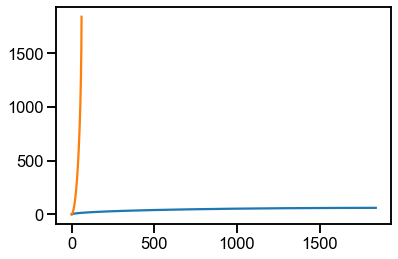

In [31]:
# Setup once
forward_spline, inverse_spline = setup_inverse_f1_spline(r_M=59.0, l_hg=2.35, N_gag=3700)

# Convert theory radius to theory number of gags
theory_ngags_1 = inverse_spline(rhoGags)
theory_radius_1 = np.sqrt(59.0 ** 2 - (59.0 - theory_ngags_1 * (4 * 59.0) / (3700 * 2))** 2)

plt.plot(forward_spline.x, forward_spline.y)
plt.plot(inverse_spline.x, inverse_spline.y)

### 6.2.6. Plug back to the Circumscribing cylindrical coordinate results

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_95008/1357701491.py:36: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


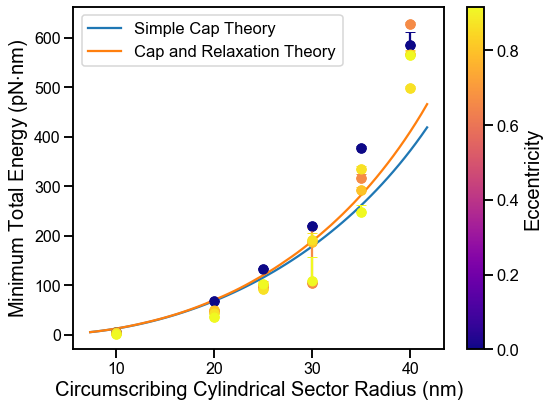

In [57]:
# Get theoretical gag lattice radius
theory_radius = rhoGags

# calculate cap eb with sga, note that with / without sga, the cap shape and energy is the same
theory_eb, theory_eb_add_relax_with_sga  = theory_function_eb(rhoGags) 

# get data for theoretical curve without sga
theory_eb_add_relax = theory_eb + ebs_nparray

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot theory curves
plt.plot(theory_radius_1, theory_eb, label = "Simple Cap Theory")
plt.plot(theory_radius_1, theory_eb_add_relax, label = "Cap and Relaxation Theory")

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    plt.scatter(subset['SizeGroup'], subset['Etot'],
             marker='o', linestyle='-', color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['SizeGroup'], subset['Etot'],
                 yerr=[np.zeros(len(subset['Etot_err'])), subset['Etot_err']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=1.0)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')

# Labels and title
plt.xlabel("Circumscribing Cylindrical Sector Radius (nm)", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Etot_vs_CCSR_by_Ecc_no_SGA_theory.svg'), format='svg')

plt.show()


### 6.2.7. Note that, `SGA` is a poor estimation here, as it digresses greatly with large cap size

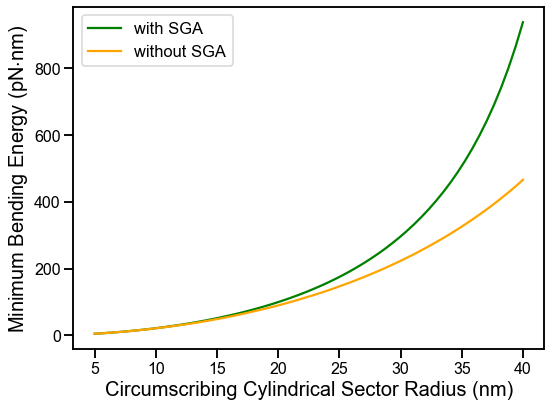

In [34]:
plt.figure(figsize=(8, 6))

# Plot theory curves
# Plot theory curves
plt.plot(theory_radius, theory_eb_add_relax_with_sga, label = "with SGA", c = 'g')
plt.plot(theory_radius, ebs_nparray + theory_eb, label = "without SGA", c = 'orange')

# Labels and title
plt.xlabel("Circumscribing Cylindrical Sector Radius (nm)", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_CCSR_by_Ecc_theory_compare.svg'), format='svg')

plt.show()


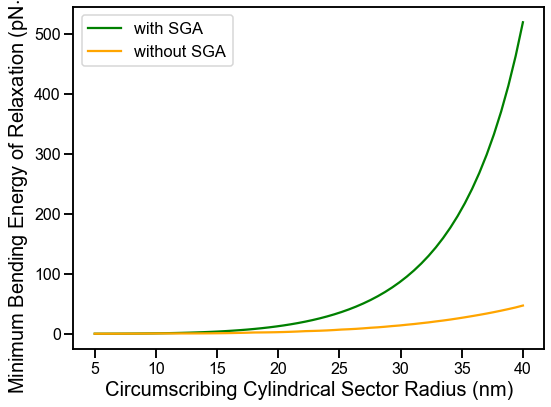

In [35]:
plt.figure(figsize=(8, 6))

# Plot theory curves
# Plot theory curves
plt.plot(theory_radius, theory_eb_add_relax_with_sga - theory_eb, label = "with SGA", c = 'g')
plt.plot(theory_radius, ebs_nparray, label = "without SGA", c = 'orange')

# Labels and title
plt.xlabel("Circumscribing Cylindrical Sector Radius (nm)", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy of Relaxation (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_relax_vs_CCSR_by_Ecc_theory_compare.svg'), format='svg')

plt.show()


# 7. Plot `EB` vs `Ecc` by `Ngags`

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_95008/3088416298.py:22: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


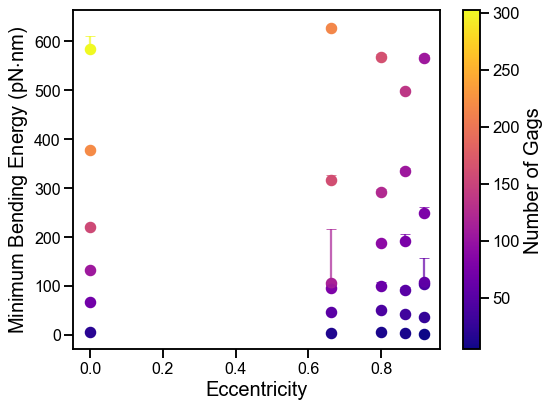

In [42]:
# Create colormap
unique_ngags = grouped_df['Ngags'].unique()
norm = mcolors.Normalize(vmin=min(unique_ngags), vmax=max(unique_ngags))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
for ngags in unique_ngags:
    subset = grouped_df[grouped_df['Ngags'] == ngags]
    plt.scatter(subset['Ecc'], subset['EB'],
             s=100, color=cmap(norm(ngags)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ecc'], subset['EB'],
                 yerr=[subset['EB'] - subset['EB_err_l'], subset['EB_err_u'] - subset['EB']],
                 fmt='o', capsize=5, color=cmap(norm(ngags)), alpha=0.7)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Number of Gags", fontsize=20, fontname='Arial')

# Labels and title
plt.xlabel("Eccentricity", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_Ecc_by_Ngags.svg'), format='svg')

plt.show()


## 7.2. The membrane bending energy cost increases more rapidly for larger lattices

For smaller lattices (green), increases in eccentricity have modest impact on the bending energy. For larger lattices (orange and blue), the energy grows more rapidly with eccentricity. The minimized bending energy of the membrane when attached to gag lattice assembled with Monte-Carlo method versus the eccentricities, grouped by the number of gags with a ±5% tolerance in each group

"Modify this figure. Do not use a color bar in a bar graph. For each Ecc. Group, choose 3 or 4 lattice sizes. Use the same sizes for each group. Then there are 3 or 4 colors, that’s it. People are used to seeing the same bars in each group, and then looking for trends from one group to the next. So it should show that for small lattices, the bars don’t change size that much, whereas for the large lattices, the energy changes much more significantly. So use a black bar, a blue bar, a pink bar,  and an orange bar, for example. No gradients!"

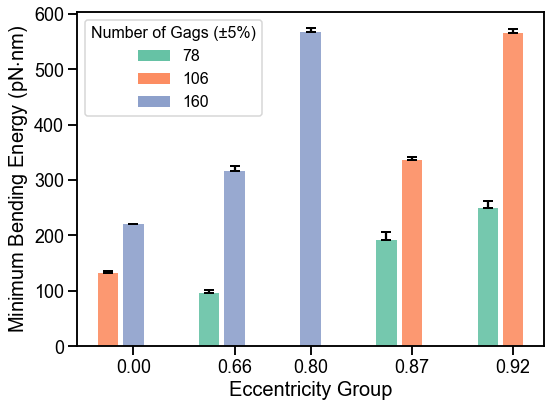

In [41]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import numpy as np
import os

# Filter out rows where Barplot == -1
filtered_df = grouped_df[grouped_df['Barplot'] != -1].copy()

# Get unique Barplot categories
unique_barplot_values = sorted(filtered_df['Barplot'].unique())
color_list = plt.get_cmap('Set2').colors  # Or 'tab10', 'tab20', etc.

# Map each Barplot value to a unique color
color_map = {val: color_list[i % len(color_list)] for i, val in enumerate(unique_barplot_values)}

plt.figure(figsize=(8, 6))

# Prepare for grouped bar plotting
group_spacing = 2  # spacing between eccentricity groups
bar_spacing = 1    # spacing between bars within a group
x_positions = []
bar_labels = []
bar_colors = []
ecc_tick_positions = []
ecc_tick_labels = []

current_x = 0
for ecc, group in filtered_df.groupby('Ecc'):
    group = group.sort_values(by='Ngags')  # Optional: consistent order within group
    for _, row in group.iterrows():
        x_positions.append(current_x)
        bar_labels.append("")  # Leave individual bar labels empty
        bar_colors.append(color_map[row['Barplot']])
        current_x += bar_spacing
    # Add group label at the middle of group
    middle_x = x_positions[-len(group)//2]
    ecc_tick_positions.append(middle_x)
    ecc_tick_labels.append(f"{ecc:.2f}")
    current_x += group_spacing  # space before next group

# Convert y values and error bars
y_vals = filtered_df['EB'].values

y_errs_upper = filtered_df['EB_err_u'].values - filtered_df['EB'].values
y_errs_lower = filtered_df['EB'].values - filtered_df['EB_err_l'].values
y_errs = np.vstack([y_errs_lower, y_errs_upper])  # shape (2, N)

# Plot the bars
plt.bar(x_positions, y_vals, color=bar_colors, alpha=0.9)

_, cl, _ = plt.errorbar(
    x_positions, y_vals, yerr=y_errs, fmt='none',
    ecolor='black', capsize=5, capthick=2, lolims=True
)
cl[0].set_marker('_')
cl[1].set_marker('_')

# Set x-ticks only at group midpoints
plt.xticks(ecc_tick_positions, ecc_tick_labels, fontsize=18, fontname='Arial')

# Legend for qualitative Barplot values
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[val], label=f'{val}') for val in unique_barplot_values]
plt.legend(handles=legend_elements, title='Number of Gags (±5%)', fontsize=16, title_fontsize=16)

# Axis labels
plt.xlabel("Eccentricity Group", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.yticks(fontsize=18, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'EB_vs_EccGrouped_barplot_byBarplot.svg'), format='svg')
plt.show()


## 7.3 Total Energy cost vs eccentricities

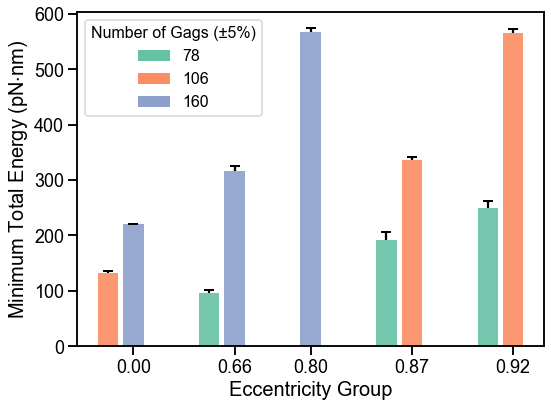

In [46]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import numpy as np
import os

# Filter out rows where Barplot == -1
filtered_df = grouped_df[grouped_df['Barplot'] != -1].copy()

# Get unique Barplot categories
unique_barplot_values = sorted(filtered_df['Barplot'].unique())
color_list = plt.get_cmap('Set2').colors  # Or 'tab10', 'tab20', etc.

# Map each Barplot value to a unique color
color_map = {val: color_list[i % len(color_list)] for i, val in enumerate(unique_barplot_values)}

plt.figure(figsize=(8, 6))

# Prepare for grouped bar plotting
group_spacing = 2  # spacing between eccentricity groups
bar_spacing = 1    # spacing between bars within a group
x_positions = []
bar_labels = []
bar_colors = []
ecc_tick_positions = []
ecc_tick_labels = []

current_x = 0
for ecc, group in filtered_df.groupby('Ecc'):
    group = group.sort_values(by='Ngags')  # Optional: consistent order within group
    for _, row in group.iterrows():
        x_positions.append(current_x)
        bar_labels.append("")  # Leave individual bar labels empty
        bar_colors.append(color_map[row['Barplot']])
        current_x += bar_spacing
    # Add group label at the middle of group
    middle_x = x_positions[-len(group)//2]
    ecc_tick_positions.append(middle_x)
    ecc_tick_labels.append(f"{ecc:.2f}")
    current_x += group_spacing  # space before next group

# Convert y values and error bars
y_vals = filtered_df['Etot'].values

y_errs_upper = filtered_df['Etot_err'].values
y_errs_lower = np.zeros(len(y_errs_upper))
y_errs = np.vstack([y_errs_lower, y_errs_upper])  # shape (2, N)

# Plot the bars
plt.bar(x_positions, y_vals, color=bar_colors, alpha=0.9)

_, cl, _ = plt.errorbar(
    x_positions, y_vals, yerr=y_errs, fmt='none',
    ecolor='black', capsize=5, capthick=2, lolims=True
)
cl[0].set_marker('_')
cl[1].set_marker('')

# Set x-ticks only at group midpoints
plt.xticks(ecc_tick_positions, ecc_tick_labels, fontsize=18, fontname='Arial')

# Legend for qualitative Barplot values
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[val], label=f'{val}') for val in unique_barplot_values]
plt.legend(handles=legend_elements, title='Number of Gags (±5%)', fontsize=16, title_fontsize=16)

# Axis labels
plt.xlabel("Eccentricity Group", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.yticks(fontsize=18, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Etot_vs_EccGrouped_barplot_byBarplot.svg'), format='svg')
plt.show()


# 8. Plot Global Tension

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_95008/4074202790.py:39: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


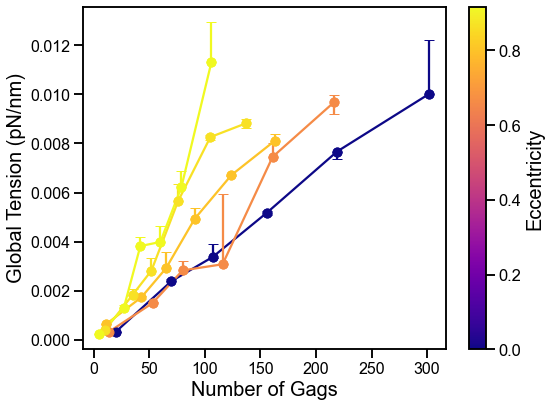

In [47]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    # subset['Tension']; subset['EA'] / subset['Etot']
    plt.plot(subset['Ngags'], subset['Tension'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ngags'], subset['Tension'],
                 yerr=[subset['Tension'] - subset['Tension_err_l'], subset['Tension_err_u'] - subset['Tension']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=1.0)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Global Tension (pN/nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Tension_vs_Ngags_by_Ecc.svg'), format='svg')

plt.show()


## 8.1. Plot global tension and Area-to-Total Ratio

0.0
0.66143782776
0.8
0.86602540378
0.91651513899


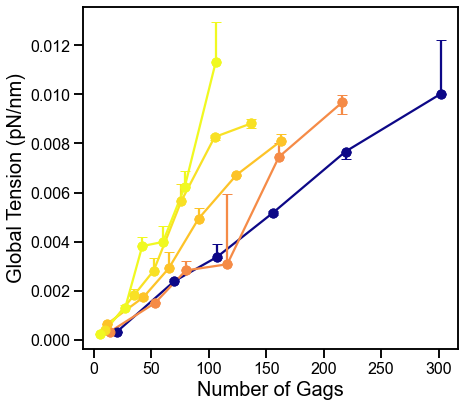

In [165]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

plt.figure(figsize=(6.8, 6))

# Plot each unique Ecc as a separate line
for ecc in unique_ecc:
    print(ecc)
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    # subset['Tension']; subset['EA'] / subset['Etot']
    plt.plot(subset['Ngags'], subset['Tension'],
             marker='o', linestyle='-', label=f"Ecc {ecc:.2f}", color=cmap(norm(ecc)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ngags'], subset['Tension'], yerr=[subset['Tension'] - subset['Tension_err_l'], subset['Tension_err_u'] - subset['Tension']], 
                 fmt='o', capsize=5, color=cmap(norm(ecc)), alpha=1.0)

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Global Tension (pN/nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Tension_vs_Ngags_by_Ecc_no_cbar.svg'), format='svg')

plt.show()


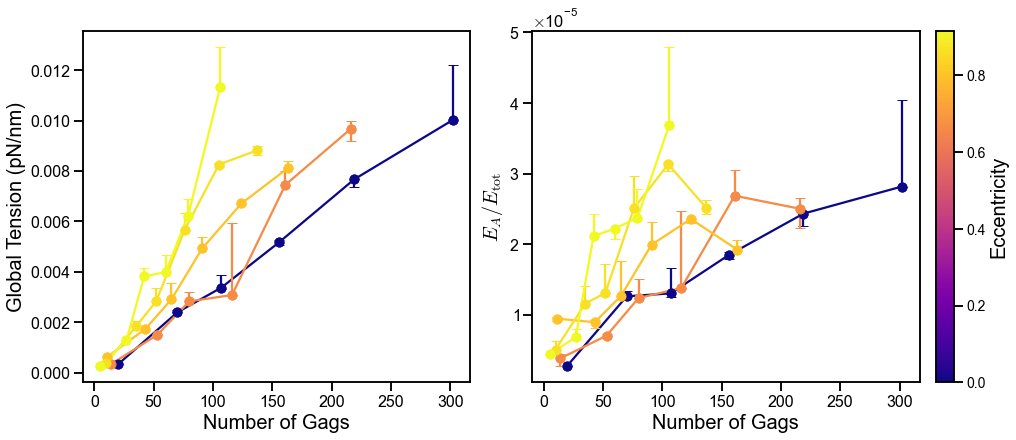

In [49]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
import numpy as np
import os

# Assume grouped_df is preloaded
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharex=True)

# ------------------- Plot 1: Global Tension -------------------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    color = cmap(norm(ecc))
    ax1.plot(subset['Ngags'], subset['Tension'], marker='o', linestyle='-', color=color)
    ax1.errorbar(
        subset['Ngags'], subset['Tension'],
        yerr=[
            subset['Tension'] - subset['Tension_err_l'],
            subset['Tension_err_u'] - subset['Tension']
        ],
        fmt='o', capsize=5, color=color, alpha=1.0
    )

ax1.set_xlabel("Number of Gags", fontsize=20, fontname='Arial')
ax1.set_ylabel("Global Tension (pN/nm)", fontsize=20, fontname='Arial')
ax1.tick_params(axis='both', labelsize=16)

# ------------------- Plot 2: EA / Etot -------------------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    yvals = subset['EA'] / subset['Etot']
    color = cmap(norm(ecc))
    ax2.plot(subset['Ngags'], yvals, marker='o', linestyle='-', color=color)
    ax2.errorbar(
        subset['Ngags'], yvals,
        yerr=[
            yvals - subset['EA_ratio_err_l'],
            subset['EA_ratio_err_u'] - yvals
        ],
        fmt='o', capsize=5, color=color, alpha=1.0
    )

ax2.set_xlabel("Number of Gags", fontsize=20, fontname='Arial')
ax2.set_ylabel(r"$E_A / E_{\mathrm{tot}}$", fontsize=20)
ax2.tick_params(axis='both', labelsize=16)
ax2.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))

# ------------------- Shared Colorbar -------------------
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], location='right', pad=0.02)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')
cbar.ax.tick_params(labelsize=14)

# ------------------- Save & Show -------------------
plt.savefig(os.path.join(output_dir, 'Tension_EAEtot_vs_Ngags_by_Ecc.svg'), format='svg')
plt.show()


# 9. Calculate Harmonic Bond Energy and Regularization Energy

In [50]:
grouped_df["EHB"] = grouped_df["Etot"] - grouped_df["EA"] - grouped_df["EB"] - grouped_df["ER"]
grouped_df

FolderName  RelaxArea         EB        EA  \
TrialGroup SizeGroup                                               
0          10         _ecca10_01    74000.0    5.82954  0.000016   
           20         _ecca20_01    74000.0   67.22260  0.000846   
           25         _ecca25_04    75500.0  131.92200  0.001716   
           30         _ecca30_04    75500.0  219.94600  0.004056   
           35         _ecca44_31    78000.0  377.34300  0.009175   
           40         _ecca43_01    82000.0  584.87000  0.016471   
1          10         _ecca10_13    75000.0    4.41255  0.000017   
           20         _ecca20_13    75000.0   47.83820  0.000335   
           25         _ecca25_12    74500.0   96.39730  0.001190   
           30         _ecca30_16    76500.0  105.34700  0.001449   
           35         _ecca35_16    76500.0  316.36600  0.008495   
           40         _ecca42_05    84000.0  627.90700  0.015703   
2          10         _ecca10_21    74000.0    6.19292  0.000058   
           20         _ecca20_22    74500.0   50.31450  0.000449   
           25         _ecca25_23    75000.0  100.73600  0.001269   
           30         _ecca30_26    76500.0  187.04500  0.003726   
           35         _ecca35_26    76500.0  292.69700  0.006896   
           40         _ecca42_13    83000.0  567.87300  0.010918   
3          10         _ecca10_33    76000.0    4.39010  0.000022   
           20         _ecca20_33    75000.0   43.41970  0.000502   
           25         _ecca25_34    75500.0   91.97770  0.001202   
           30         _ecca30_34    75500.0  192.35100  0.004824   
           35         _ecca35_37    77000.0  335.42800  0.010503   
           40         _ecca41_36    80500.0  497.93500  0.012520   
4          10         _ecca10_41    74000.0    2.06577  0.000009   
           20         _ecca20_44    75500.0   36.39130  0.000246   
           25         _ecca25_43    75000.0  103.52300  0.002187   
           30         _ecca30_45    76000.0  108.79400  0.002415   
           35         _ecca35_45    76000.0  248.91800  0.005902   
           40         _ecca41_48    81500.0  565.26500  0.020884   

                                ER       Etot  MeanForce  Ngags  SizeGroup  \
TrialGroup SizeGroup                                                         
0          10         8.334640e-04    5.85068   0.000115     20         10   
           20         0.000000e+00   67.24280   0.000464     70         20   
           25         0.000000e+00  131.93000   0.000650    107         25   
           30         0.000000e+00  219.95700   0.001183    156         30   
           35         0.000000e+00  377.36200   0.001387    219         35   
           40         0.000000e+00  584.93800   0.001363    302         40   
1          10         3.139850e-03    4.42141   0.000140     14         10   
           20         0.000000e+00   47.85790   0.001738     53         20   
           25         0.000000e+00   96.40480   0.000502     80         25   
           30         0.000000e+00  105.35700   0.000371    116         30   
           35         0.000000e+00  316.38000   0.000920    161         35   
           40         0.000000e+00  627.94000   0.001270    216         40   
2          10         5.690060e-03    6.20265   0.000254     11         10   
           20         0.000000e+00   50.32890   0.000852     43         20   
           25         7.277960e-08  100.74400   0.000408     65         25   
           30         4.930300e-09  187.05300   0.000663     91         30   
           35         0.000000e+00  292.70800   0.000715    124         35   
           40         0.000000e+00  567.88700   0.000798    163         40   
3          10         3.512640e-03    4.39852   0.000057     10         10   
           20         1.832160e-03   43.43520   0.000393     35         20   
           25         1.169370e-10   91.98720   0.000633     52         25   
           30         0.000000e+00  192.36500   0.0

## 9.1. Plot Regularization Energy and Harmonic bond Energy

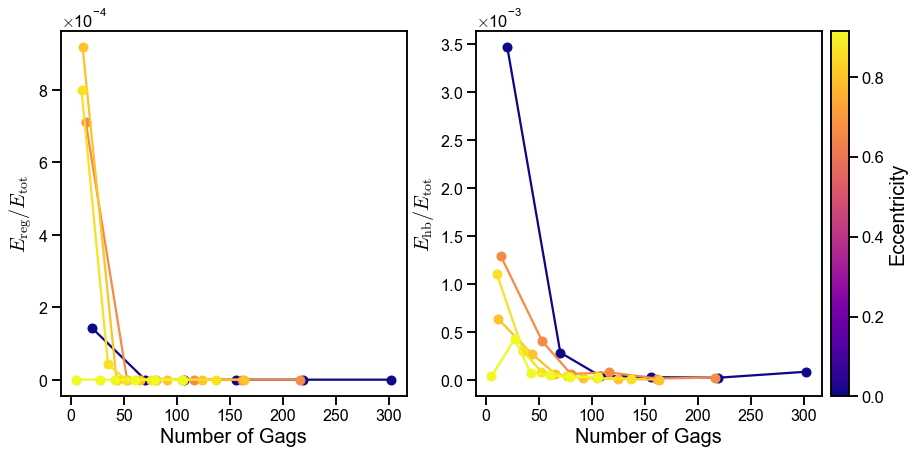

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
import os

# Sample DataFrame assumed preloaded
# grouped_df = pd.read_csv("your_data.csv")

# Create colormap
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# ---------- First subplot: ER / Etot ----------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    ax1.plot(subset['Ngags'], subset['ER'] / subset['Etot'],
             marker='o', linestyle='-', color=cmap(norm(ecc)))

# ---------- Second subplot: EHB / Etot ----------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    ax2.plot(subset['Ngags'], subset['EHB'] / subset['Etot'],
             marker='o', linestyle='-', color=cmap(norm(ecc)))

# ---------- Shared Colorbar ----------
plt.tight_layout()
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], pad=0.01)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')

# ---------- Axis Labels ----------
ax1.set_xlabel("Number of Gags", fontsize=20, fontname='Arial')
ax1.set_ylabel(r"$E_{\mathrm{reg}} / E_{\mathrm{tot}}$", fontsize=20, fontname='Arial')
ax2.set_xlabel("Number of Gags", fontsize=20, fontname='Arial')
ax2.set_ylabel(r"$E_{\mathrm{hb}} / E_{\mathrm{tot}}$", fontsize=20, fontname='Arial')

# ---------- Ticks ----------
for ax in (ax1, ax2):
    ax.tick_params(labelsize=16)
    ax.tick_params(axis='both', which='major')
    ax.set_xticks(ax.get_xticks())  # Optional: force consistent x-ticks
    # Use scientific formatter
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)

# Determine min and max Ngags across all groups
x_min = grouped_df['Ngags'].min()
x_max = grouped_df['Ngags'].max()

# Add a small margin (e.g., 5%) to either side
x_margin = (x_max - x_min) * 0.05
x_lower = x_min - x_margin
x_upper = x_max + x_margin

# Apply to both axes
ax1.set_xlim(x_lower, x_upper)
ax2.set_xlim(x_lower, x_upper)
    
plt.savefig(os.path.join(output_dir, 'ER_EHB_vs_Ngags_by_Ecc.svg'), format='svg')
plt.show()


## 9.2. EB_EA_ER_EHB vs Ngags by Ecc

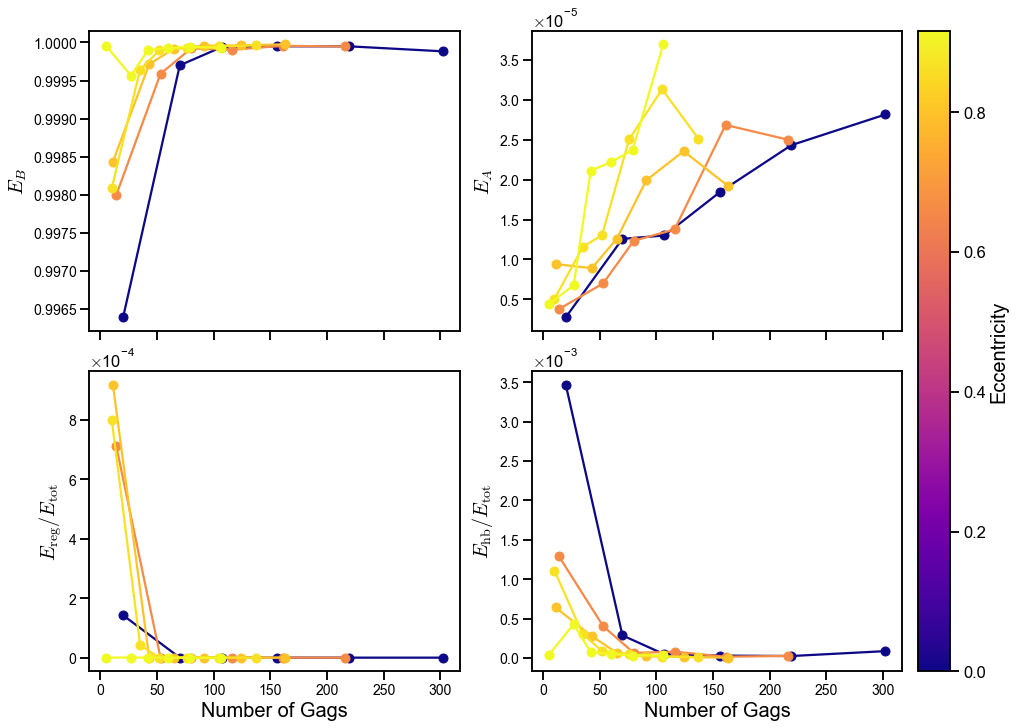

In [53]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
import numpy as np
import os

# Colormap setup
unique_ecc = grouped_df['Ecc'].unique()
norm = mcolors.Normalize(vmin=min(unique_ecc), vmax=max(unique_ecc))
cmap = cm.plasma

# Get shared x-axis limits
x_min = grouped_df['Ngags'].min()
x_max = grouped_df['Ngags'].max()
x_margin = (x_max - x_min) * 0.05
x_lower = x_min - x_margin
x_upper = x_max + x_margin

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, constrained_layout=True)
(ax00, ax01), (ax10, ax11) = axes

# ----------------- EB / Etot (top left) -----------------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    ax00.plot(subset['Ngags'], subset['EB'] / subset['Etot'],
              marker='o', linestyle='-', color=cmap(norm(ecc)))

ax00.set_ylabel(r"$E_B} / E_{\mathrm{tot}}$", fontsize=20, fontname='Arial')

# ----------------- EA / Etot (top right) -----------------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    ax01.plot(subset['Ngags'], subset['EA'] / subset['Etot'],
              marker='o', linestyle='-', color=cmap(norm(ecc)))

ax01.set_ylabel(r"$E_A} / E_{\mathrm{tot}}$", fontsize=20, fontname='Arial')

# ----------------- ER / Etot (bottom left) -----------------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    ax10.plot(subset['Ngags'], subset['ER'] / subset['Etot'],
              marker='o', linestyle='-', color=cmap(norm(ecc)))

ax10.set_xlabel("Number of Gags", fontsize=20, fontname='Arial')
ax10.set_ylabel(r"$E_{\mathrm{reg}} / E_{\mathrm{tot}}$", fontsize=20, fontname='Arial')

# ----------------- EHB / Etot (bottom right) -----------------
for ecc in unique_ecc:
    subset = grouped_df[grouped_df['Ecc'] == ecc]
    ax11.plot(subset['Ngags'], subset['EHB'] / subset['Etot'],
              marker='o', linestyle='-', color=cmap(norm(ecc)))

ax11.set_xlabel("Number of Gags", fontsize=20, fontname='Arial')
ax11.set_ylabel(r"$E_{\mathrm{hb}} / E_{\mathrm{tot}}$", fontsize=20, fontname='Arial')

# ----------------- Shared formatting -----------------
for ax in [ax00, ax01, ax10, ax11]:
    ax.set_xlim(x_lower, x_upper)
    ax.tick_params(labelsize=14)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)

# ----------------- Shared colorbar -----------------
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax00, ax01, ax10, ax11], location='right', pad=0.02)
cbar.set_label("Eccentricity", fontsize=20, fontname='Arial')

# ----------------- Save and Show -----------------
plt.savefig(os.path.join(output_dir, 'EB_EA_ER_EHB_vs_Ngags_by_Ecc.svg'), format='svg')
plt.show()
